# Upper-Funnel Marketing Mix Model with a Search Mediator

In a lot of marketing data, some channels don't just drive sales on their own — they also push people toward *other* channels. In our data, `Broadcast` and `Streaming` ads are the awareness-building, "upper funnel" spend. The idea we want to test is that this spend doesn't just influence revenue directly — it also makes people search for the product more, which shows up in the `Search` channel.

If we build a normal model where `Search` sits next to every other channel, we accidentally hide part of the story: some of the credit that belongs to `Broadcast` and `Streaming` gets stolen by `Search`, because `Search` looks like it's the one driving revenue.

This notebook builds two models on a four year weekly dataset:

1. A **standard model**, where `Search` is treated like any other channel.
2. A **funnel-aware model**, where `Search` is treated as something that partly *results from* the upper-funnel channels, not just something that sits beside them.

We then compare what each model says about how valuable the upper-funnel channels really are, and how well each model fits the data. We are not doing budget optimization or experiment-based calibration here — just figuring out how to attribute credit correctly.


## How we think about the funnel

The picture below has two groups of channels on the left and a chain of boxes on the right that explains how `Search` really works.

**The two channel groups.** `Broadcast` and `Streaming` are the **upper-funnel channels**: awareness-building spend that we think also creates search demand. `DirectMail` and `Digital` are the **lower-funnel channels**: channels we have no reason to believe feed search, so each group has one arrow labeled "direct" going straight to `revenue` and nothing else.

**The hidden demand.** The upper-funnel channels don't only drive revenue directly (their own "direct" arrow) — they also build up a "hidden search demand": people who become more likely to search for the product because they saw a `Broadcast` or `Streaming` ad. We never observe this demand directly, which is why it's drawn as a dashed node.

**The mediator.** That hidden demand combines with `search_spend` (the search team's own budget, which they control independently) into a single "mediator" value. This is also unobserved, and it stands for the total pool of search-driven interest in a given week, whether that interest came from upstream advertising or from the search team's own bidding.

**Two things the mediator explains.** The mediator does double duty:

- It is **measured by** `search_impressions`, the observed count of how often search ads were shown. Impressions are a noisy readout of the mediator, not a cause of anything downstream.
- It has its own **indirect** arrow into `revenue`, separate from the upper-funnel channels' direct arrows. This is the credit that a model would miss entirely if it treated `search_spend` or `search_impressions` as an ordinary channel.

So every dollar of upper-funnel spend can reach `revenue` two ways: directly, and indirectly through the demand it creates in search. The funnel-aware model estimates both; the standard model (described below) can only ever see the direct path.

**What the next cell does.** It builds a `graphviz.Digraph` named `dag` purely for this illustration — it is not used anywhere else in the notebook. Two `graphviz` subgraphs (`cluster_upper`, `cluster_lower`) group the channel nodes visually; `ltail` on an edge makes the arrow originate from the cluster's border rather than a single node inside it. The final bare `dag` expression renders the graph as the cell's output.



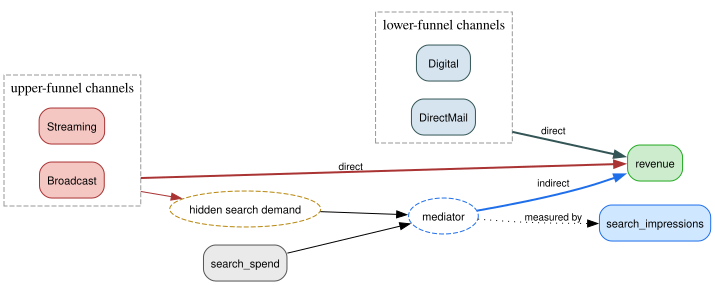

In [1]:
import graphviz as gr

dag = gr.Digraph()
dag.attr(rankdir="LR", bgcolor="transparent", compound="true")
dag.attr("node", fontname="Helvetica", fontsize="11", shape="box", style="rounded,filled")
dag.attr("edge", fontname="Helvetica", fontsize="10")

with dag.subgraph(name="cluster_upper") as c:
    c.attr(label="upper-funnel channels", style="dashed", color="gray60")
    c.node("broadcast", "Broadcast", fillcolor="#f4c7c3", color="#a33")
    c.node("streaming", "Streaming", fillcolor="#f4c7c3", color="#a33")

with dag.subgraph(name="cluster_lower") as c:
    c.attr(label="lower-funnel channels", style="dashed", color="gray60")
    c.node("directmail", "DirectMail", fillcolor="#d6e4f0", color="#355")
    c.node("digital", "Digital", fillcolor="#d6e4f0", color="#355")

dag.node("spend", "search_spend", fillcolor="#eaeaea", color="#555")
dag.node("demand", "hidden search demand", shape="ellipse", style="dashed", fillcolor="white", color="#b8860b")
dag.node("mediator", "mediator", shape="ellipse", style="dashed", fillcolor="white", color="#1f6feb")
dag.node("impressions", "search_impressions", fillcolor="#cfe8ff", color="#1f6feb")
dag.node("revenue", "revenue", fillcolor="#cdeccd", color="#2a2")

dag.edge("broadcast", "demand", color="#a33", ltail="cluster_upper")
dag.edge("spend", "mediator")
dag.edge("demand", "mediator")
dag.edge("mediator", "impressions", style="dotted", label="measured by")
dag.edge("mediator", "revenue", color="#1f6feb", penwidth="2", label="indirect")
dag.edge("broadcast", "revenue", color="#a33", penwidth="2", label="direct", ltail="cluster_upper")
dag.edge("directmail", "revenue", color="#355", penwidth="2", label="direct", ltail="cluster_lower")
dag


## Setup

Standard imports, a fixed random seed for reproducibility, and some plotting defaults. Every uncertainty interval shown later is a 94% highest-density interval (HDI).



In [2]:
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import seaborn as sns
import xarray as xr
from pydantic import InstanceOf
from pymc_extras.prior import Prior

from pymc_marketing.metrics import crps
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.data_conversion import to_mmm_dataset
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Numba will use object mode")

az.style.use("arviz-darkgrid")
HDI_PROB = 0.94
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
COLOR_DIRECT = "C0"
COLOR_INDIRECT = "C1"

%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "upper_funnel_modeling"))
rng: np.random.Generator = np.random.default_rng(seed=seed)


## Load the Data

The CSV file already contains only what this notebook uses: four media channels (two combined from related raw channels), the two search columns, a handful of grouped holiday flags, and revenue. It covers about four years of weekly data.

**Variables defined in the next cell.** These are referenced by nearly every later cell, so it's worth naming them up front:

- `data_df`: the full weekly `pandas.DataFrame` loaded from `data/media_data.csv`, with `date` parsed to a proper datetime column.
- `date_column`, `target_column`: the string column names `"date"` and `"revenue"` that `pymc-marketing`'s `MMM` expects to be told explicitly.
- `channel_columns`: the four media-spend columns (`Broadcast`, `Digital`, `DirectMail`, `Streaming`, alphabetically sorted) passed to every model as `channel_columns`.
- `upper_channels`: the subset of `channel_columns` (`Broadcast`, `Streaming`) that also feed the search mediator built later in the notebook.
- `funnel_vars`: the two extra columns (`search_spend`, `search_impressions`) the funnel-aware model needs that an ordinary `MMM` doesn't know about.
- `control_columns`: every column containing `"holiday_"`, used as additive controls in both models.
- `X`, `y`: the feature frame (`data_df` without `revenue`) and the target series, the two arguments every `MMM.fit(...)` call below takes.


In [3]:
data_df = pd.read_csv("data/media_data.csv")
data_df["date"] = pd.to_datetime(data_df["date"])

date_column = "date"
target_column = "revenue"

channel_columns = sorted(["DirectMail", "Digital", "Broadcast", "Streaming"])
upper_channels = ["Broadcast", "Streaming"]  # feed the search mediator
funnel_vars = ["search_spend", "search_impressions"]
control_columns = [col for col in data_df.columns if "holiday_" in col]

X = data_df.drop(columns=target_column)
y = data_df[target_column]

print(f"{len(data_df)} weeks, {len(channel_columns)} media channels, {len(control_columns)} holiday controls")
data_df.head()


209 weeks, 4 media channels, 5 holiday controls


,date,revenue,DirectMail,Digital,Broadcast,Streaming,search_spend,search_impressions,holiday_major_shopping,holiday_year_end,holiday_thanksgiving,holiday_long_weekends,holiday_other
0,2020-08-03,76805902.47,1057899.27,51539.96,602843.06,164514.73,348511.05,107512.49,0,0,0,0,0
1,2020-08-10,82676118.08,987342.01,117687.80,567084.69,86406.01,337105.93,106573.08,0,0,0,0,0
2,2020-08-17,72849976.48,2892612.34,64128.71,250960.76,56431.77,331788.22,98465.91,0,0,0,0,0
3,2020-08-24,73035260.71,622879.76,167124.60,276531.54,81707.04,364241.90,168459.55,0,0,0,0,0
4,2020-08-31,88883748.69,3512750.33,212356.09,677242.07,177661.23,413415.43,110371.97,0,0,0,1,0


## A Quick Look at the Data

Before modeling, it's worth checking three things: how much of the budget `Search` actually takes up, whether `search_spend` and `search_impressions` really move together, and what spending on the two upper-funnel channels looks like over time.

**The cells below, in order:**

1. A horizontal bar chart of `spend_share`, each channel's (plus `Search`'s) share of total spend, computed by concatenating `channel_columns` with a renamed `search_spend` column and normalizing by the grand total.
2. A dual-axis line plot of `search_spend` vs. `search_impressions` over time, followed by three printed Pearson correlations (`corr_sales`, `corr_pair`) against `revenue` and against each other — the premise for treating one as a noisy measurement of the other.
3. One subplot per upper-funnel channel (`upper_channels`) showing weekly spend.
4. A single line plot of weekly `revenue`.
5. A subplot per channel in `channel_columns` (all four, not just upper-funnel) showing weekly spend.
6. A `corr` correlation matrix (channels + search columns + revenue) rendered as a `seaborn.heatmap`.



Search share of the modeled media spend: 25.2%


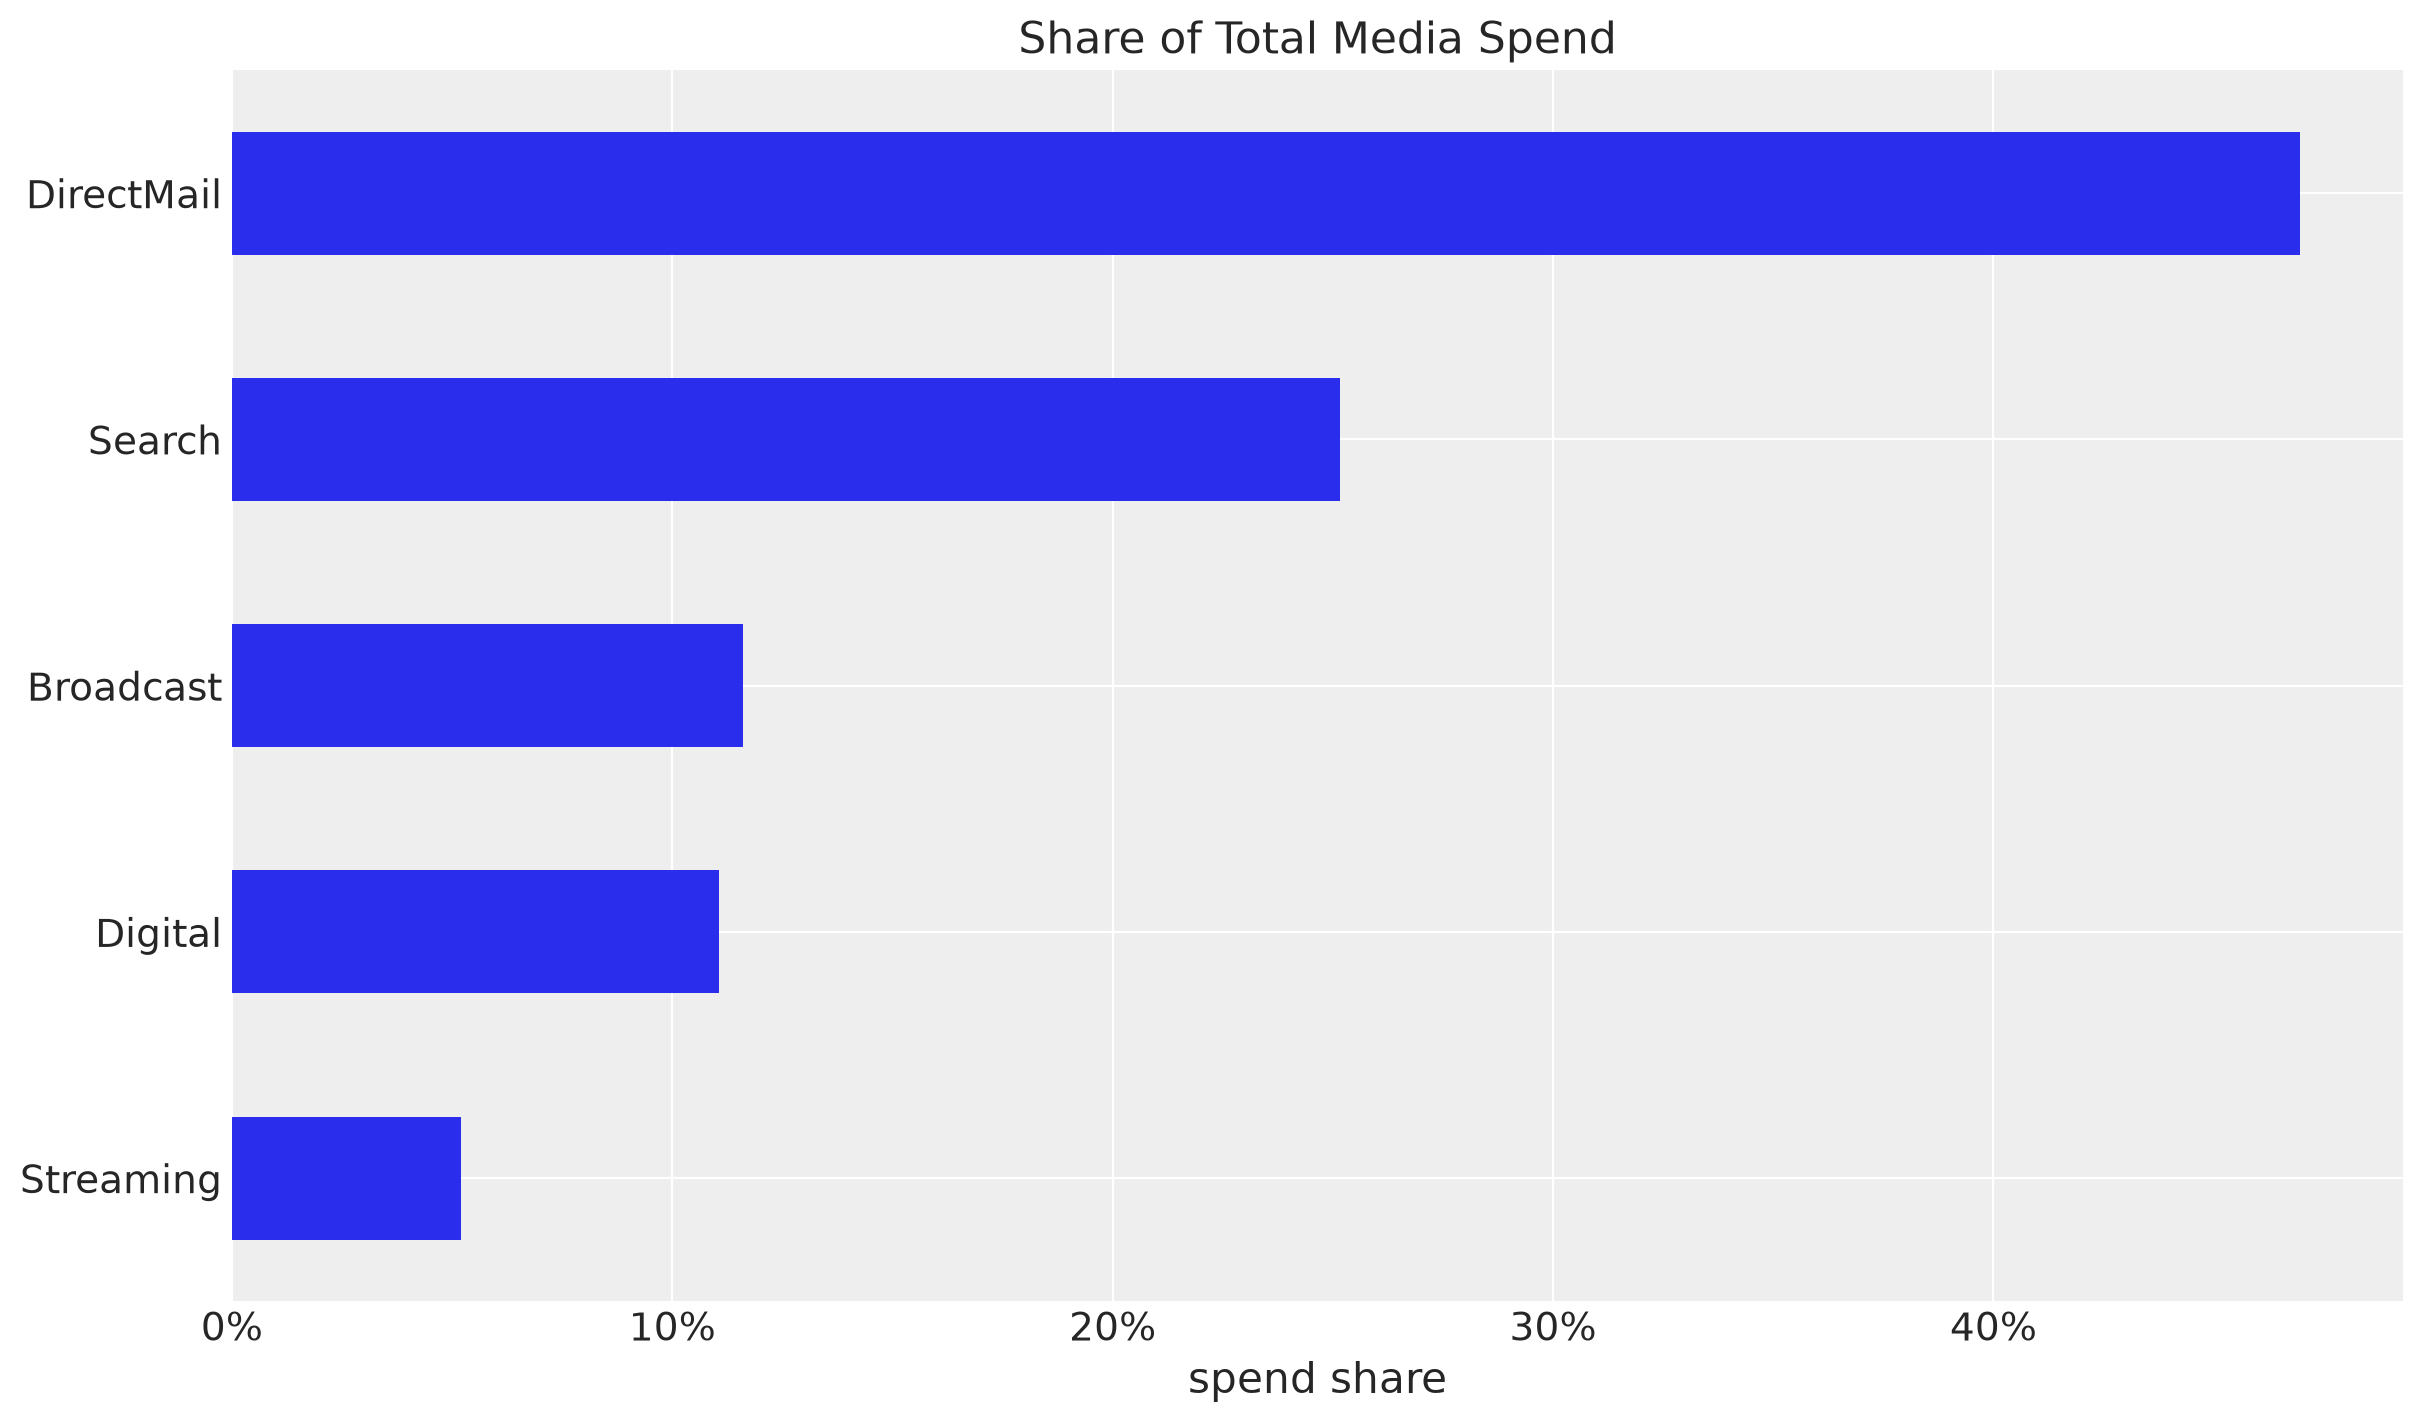

In [4]:
spend_share = (
    pd.concat(
        [X[channel_columns], X[["search_spend"]].rename(columns={"search_spend": "Search"})],
        axis=1,
    )
    .sum()
    .sort_values()
)
spend_share = spend_share / spend_share.sum()

fig, ax = plt.subplots()
colors = ["C0"]  # pandas cycles this single color across every bar
spend_share.plot.barh(color=colors, ax=ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set(title="Share of Total Media Spend", xlabel="spend share")
print(f"Search share of the modeled media spend: {spend_share['Search']:.1%}")


corr(search_spend, revenue) = 0.58
corr(search_impressions, revenue) = 0.59
corr(search_spend, search_impressions) = 0.78


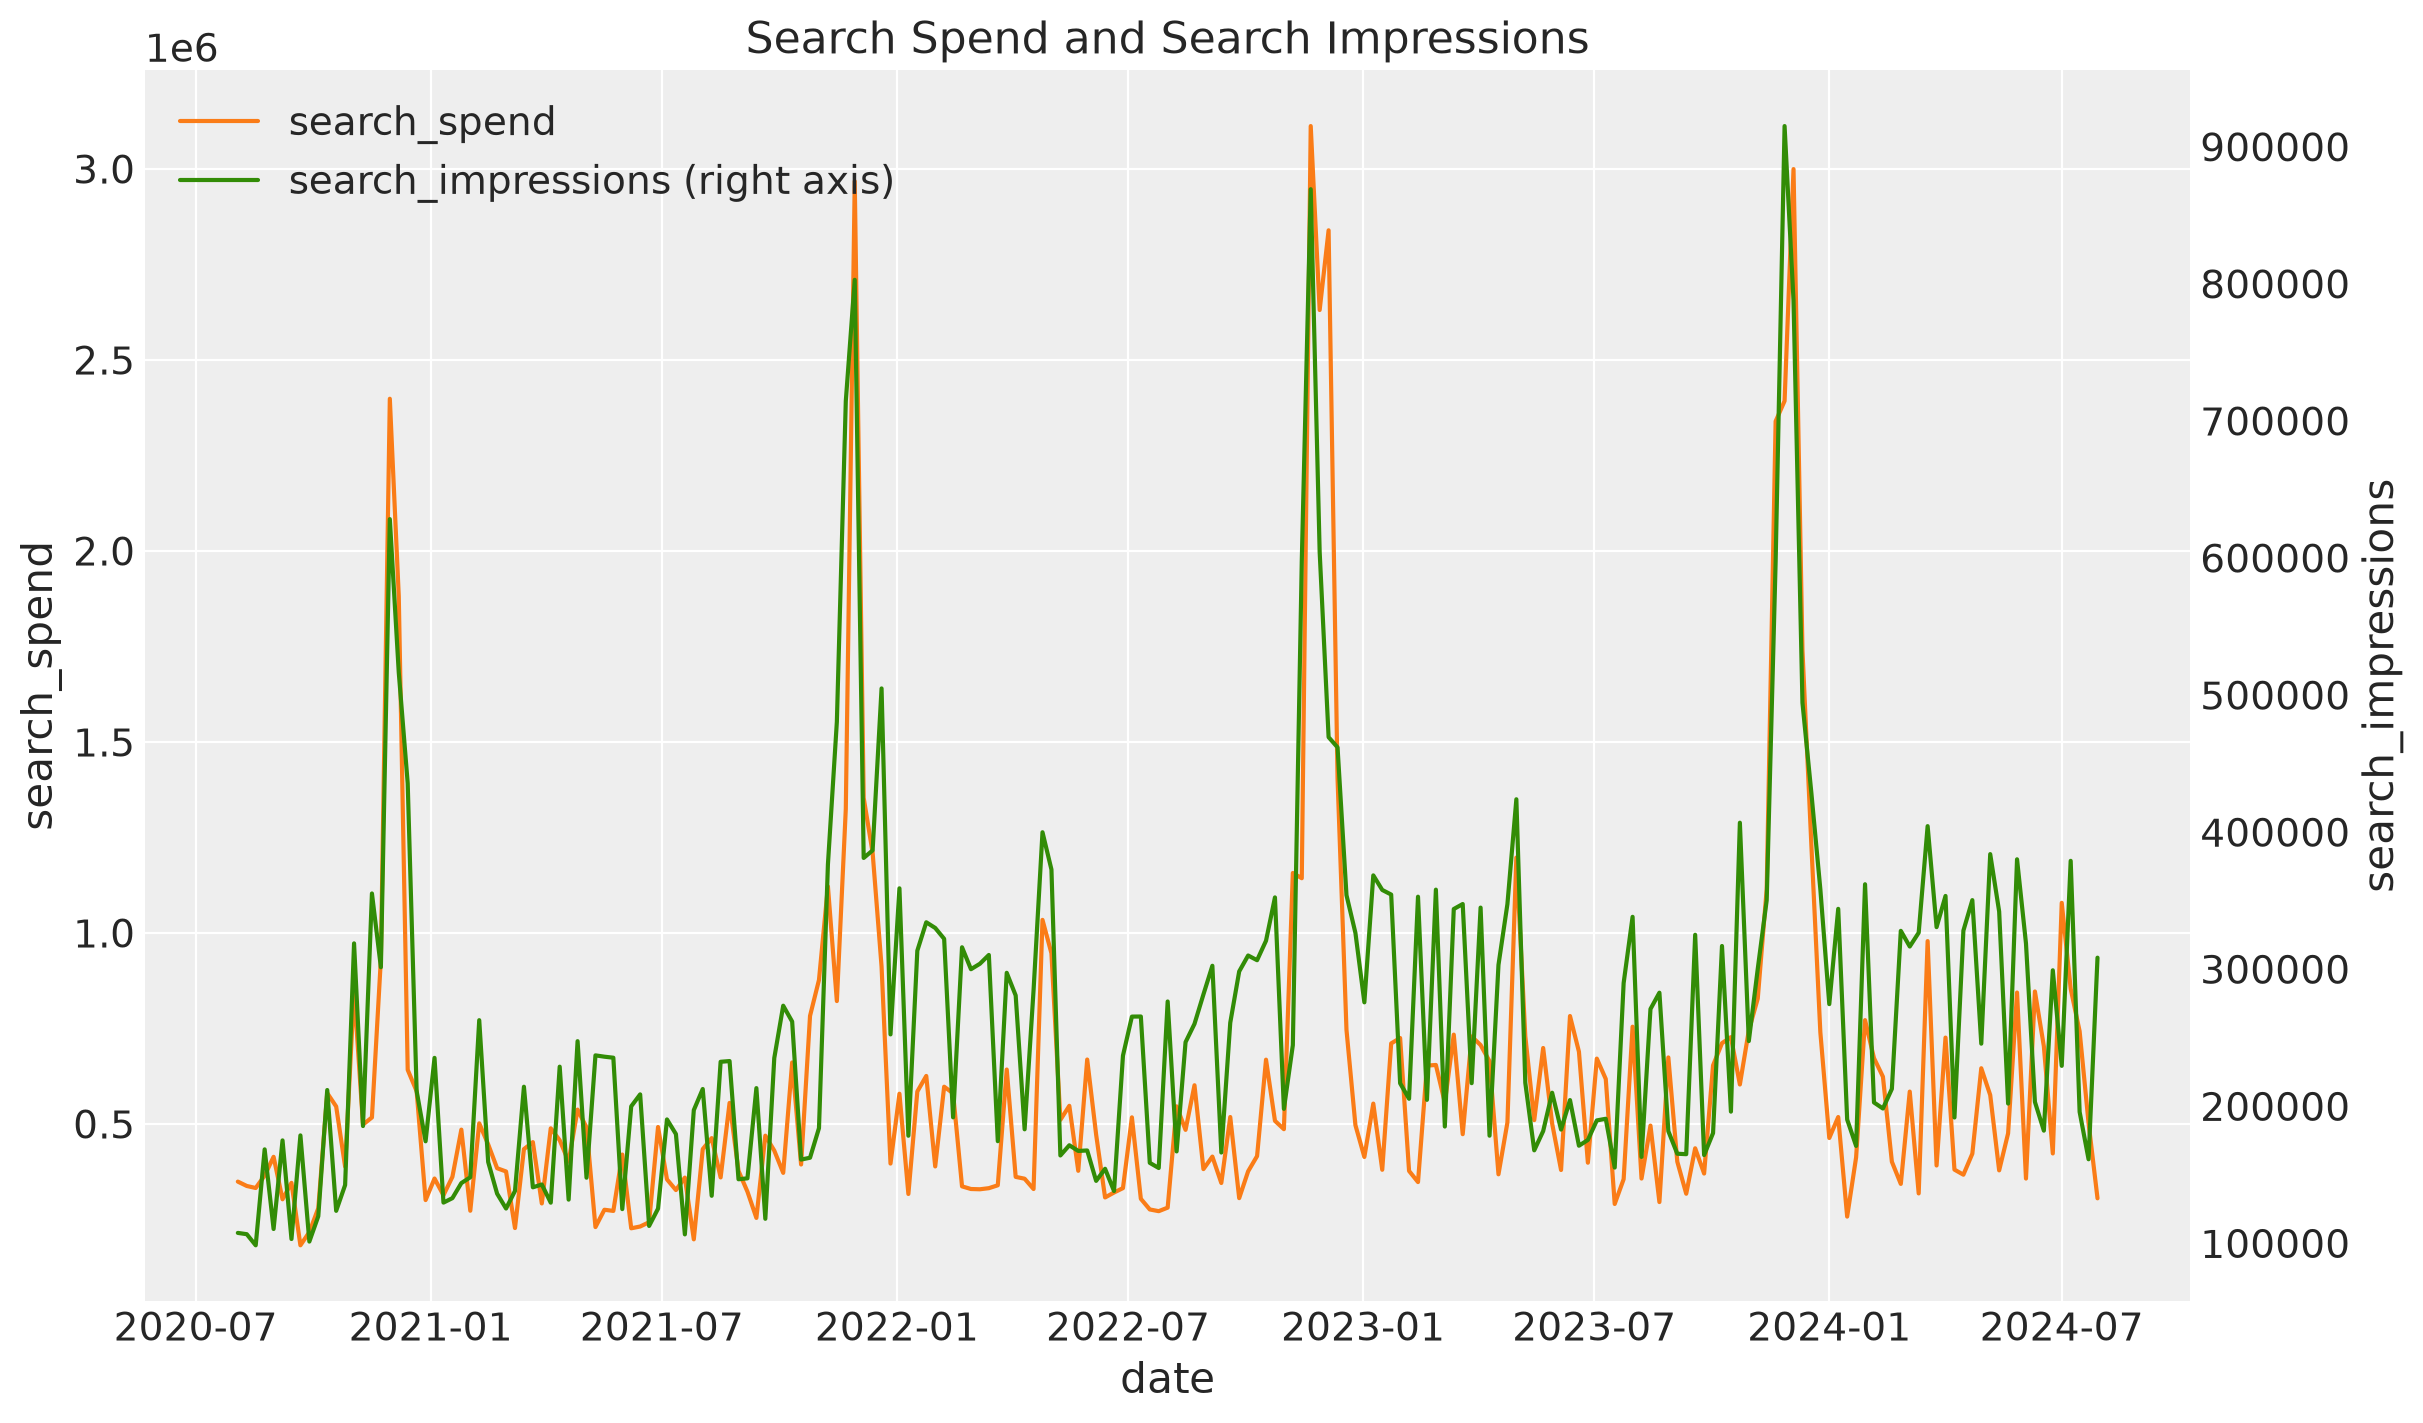

In [5]:
fig, ax = plt.subplots()
sns.lineplot(data=data_df, x=date_column, y="search_spend", color="C1", label="search_spend", ax=ax)
ax2 = ax.twinx()
sns.lineplot(
    data=data_df,
    x=date_column,
    y="search_impressions",
    color="C2",
    label="search_impressions (right axis)",
    ax=ax2,
)
ax2.grid(False)
ax2.set(ylabel="search_impressions")
handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.get_legend().remove()
ax.legend(handles + handles2, labels + labels2, loc="upper left")
ax.set(title="Search Spend and Search Impressions", ylabel="search_spend")

corr_sales = data_df[["search_spend", "search_impressions", target_column]].corr()[target_column]
corr_pair = data_df["search_spend"].corr(data_df["search_impressions"])
print(f"corr(search_spend, revenue) = {corr_sales['search_spend']:.2f}")
print(f"corr(search_impressions, revenue) = {corr_sales['search_impressions']:.2f}")
print(f"corr(search_spend, search_impressions) = {corr_pair:.2f}")


Text(0.5, 0.98, 'Weekly Spend per Upper-Funnel Channel')

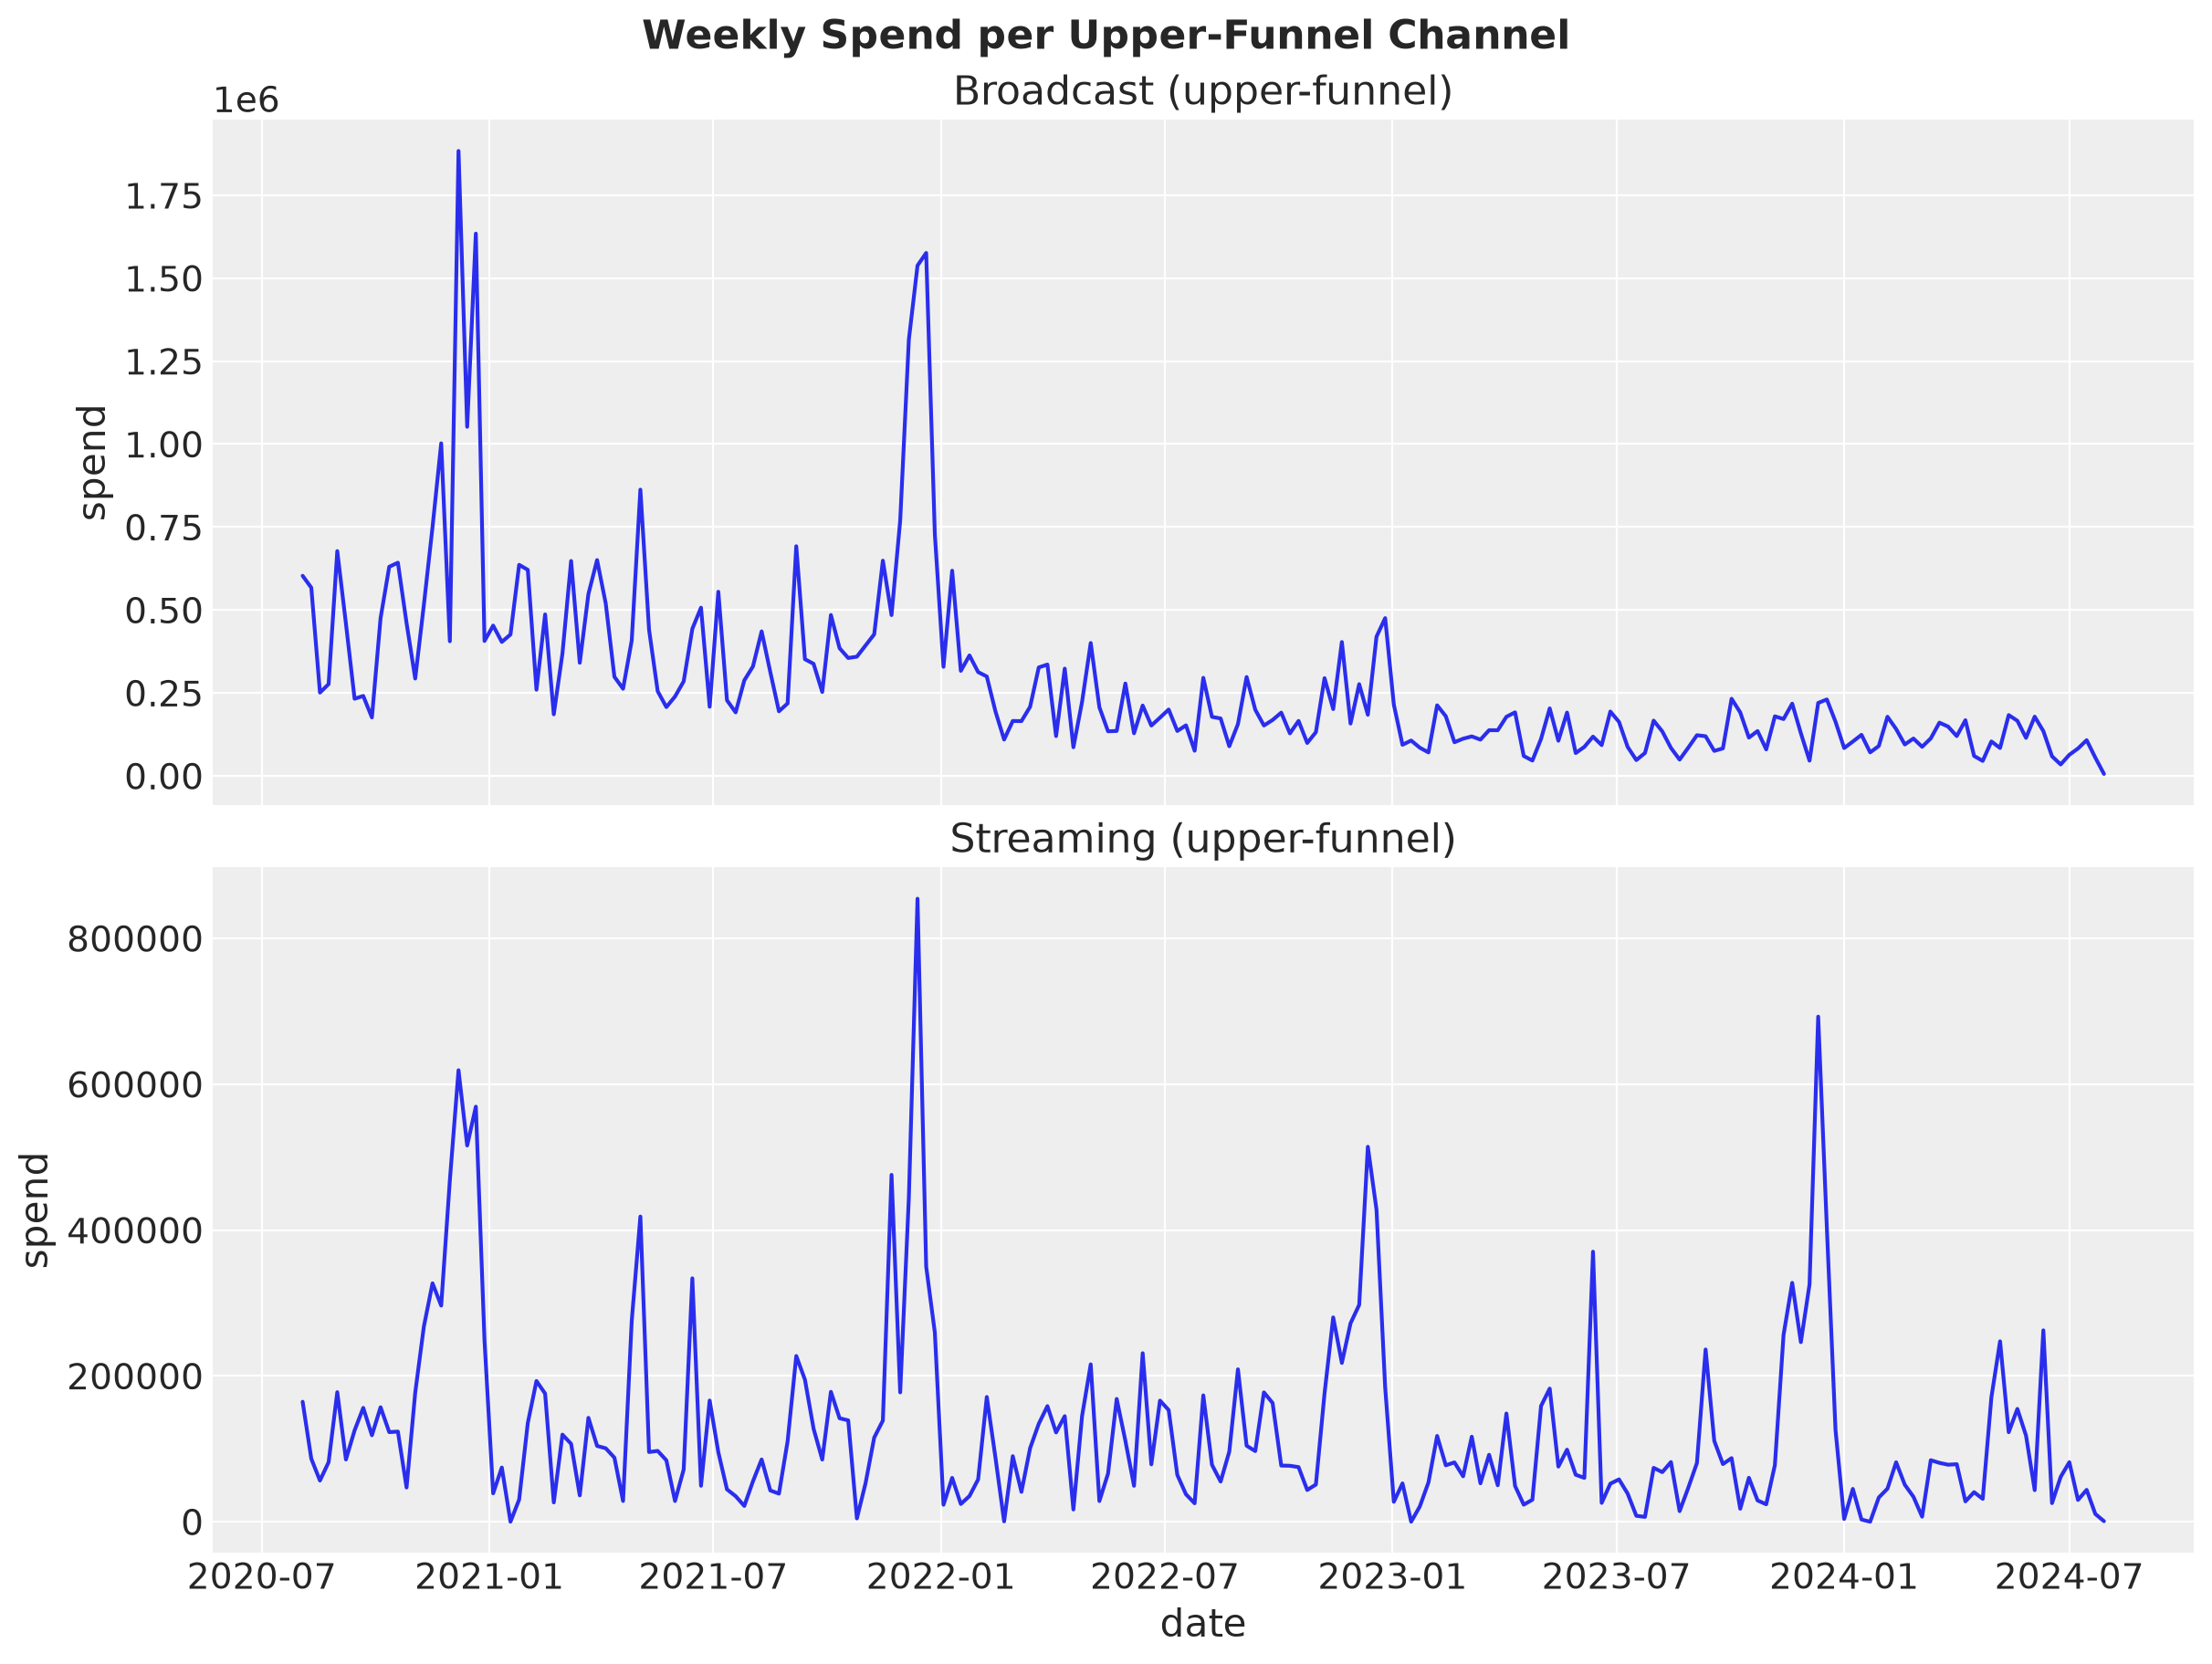

In [6]:
fig, axes = plt.subplots(nrows=len(upper_channels), ncols=1, figsize=(12, 9), sharex=True, layout="constrained")
for ax, channel in zip(axes, upper_channels, strict=True):
    sns.lineplot(data=data_df, x=date_column, y=channel, color="C0", ax=ax)
    ax.set(title=f"{channel} (upper-funnel)", ylabel="spend")
fig.suptitle("Weekly Spend per Upper-Funnel Channel", fontsize=16, fontweight="bold")


[Text(0.5, 1.0, 'Weekly Revenue Over Time'), Text(0, 0.5, 'revenue')]

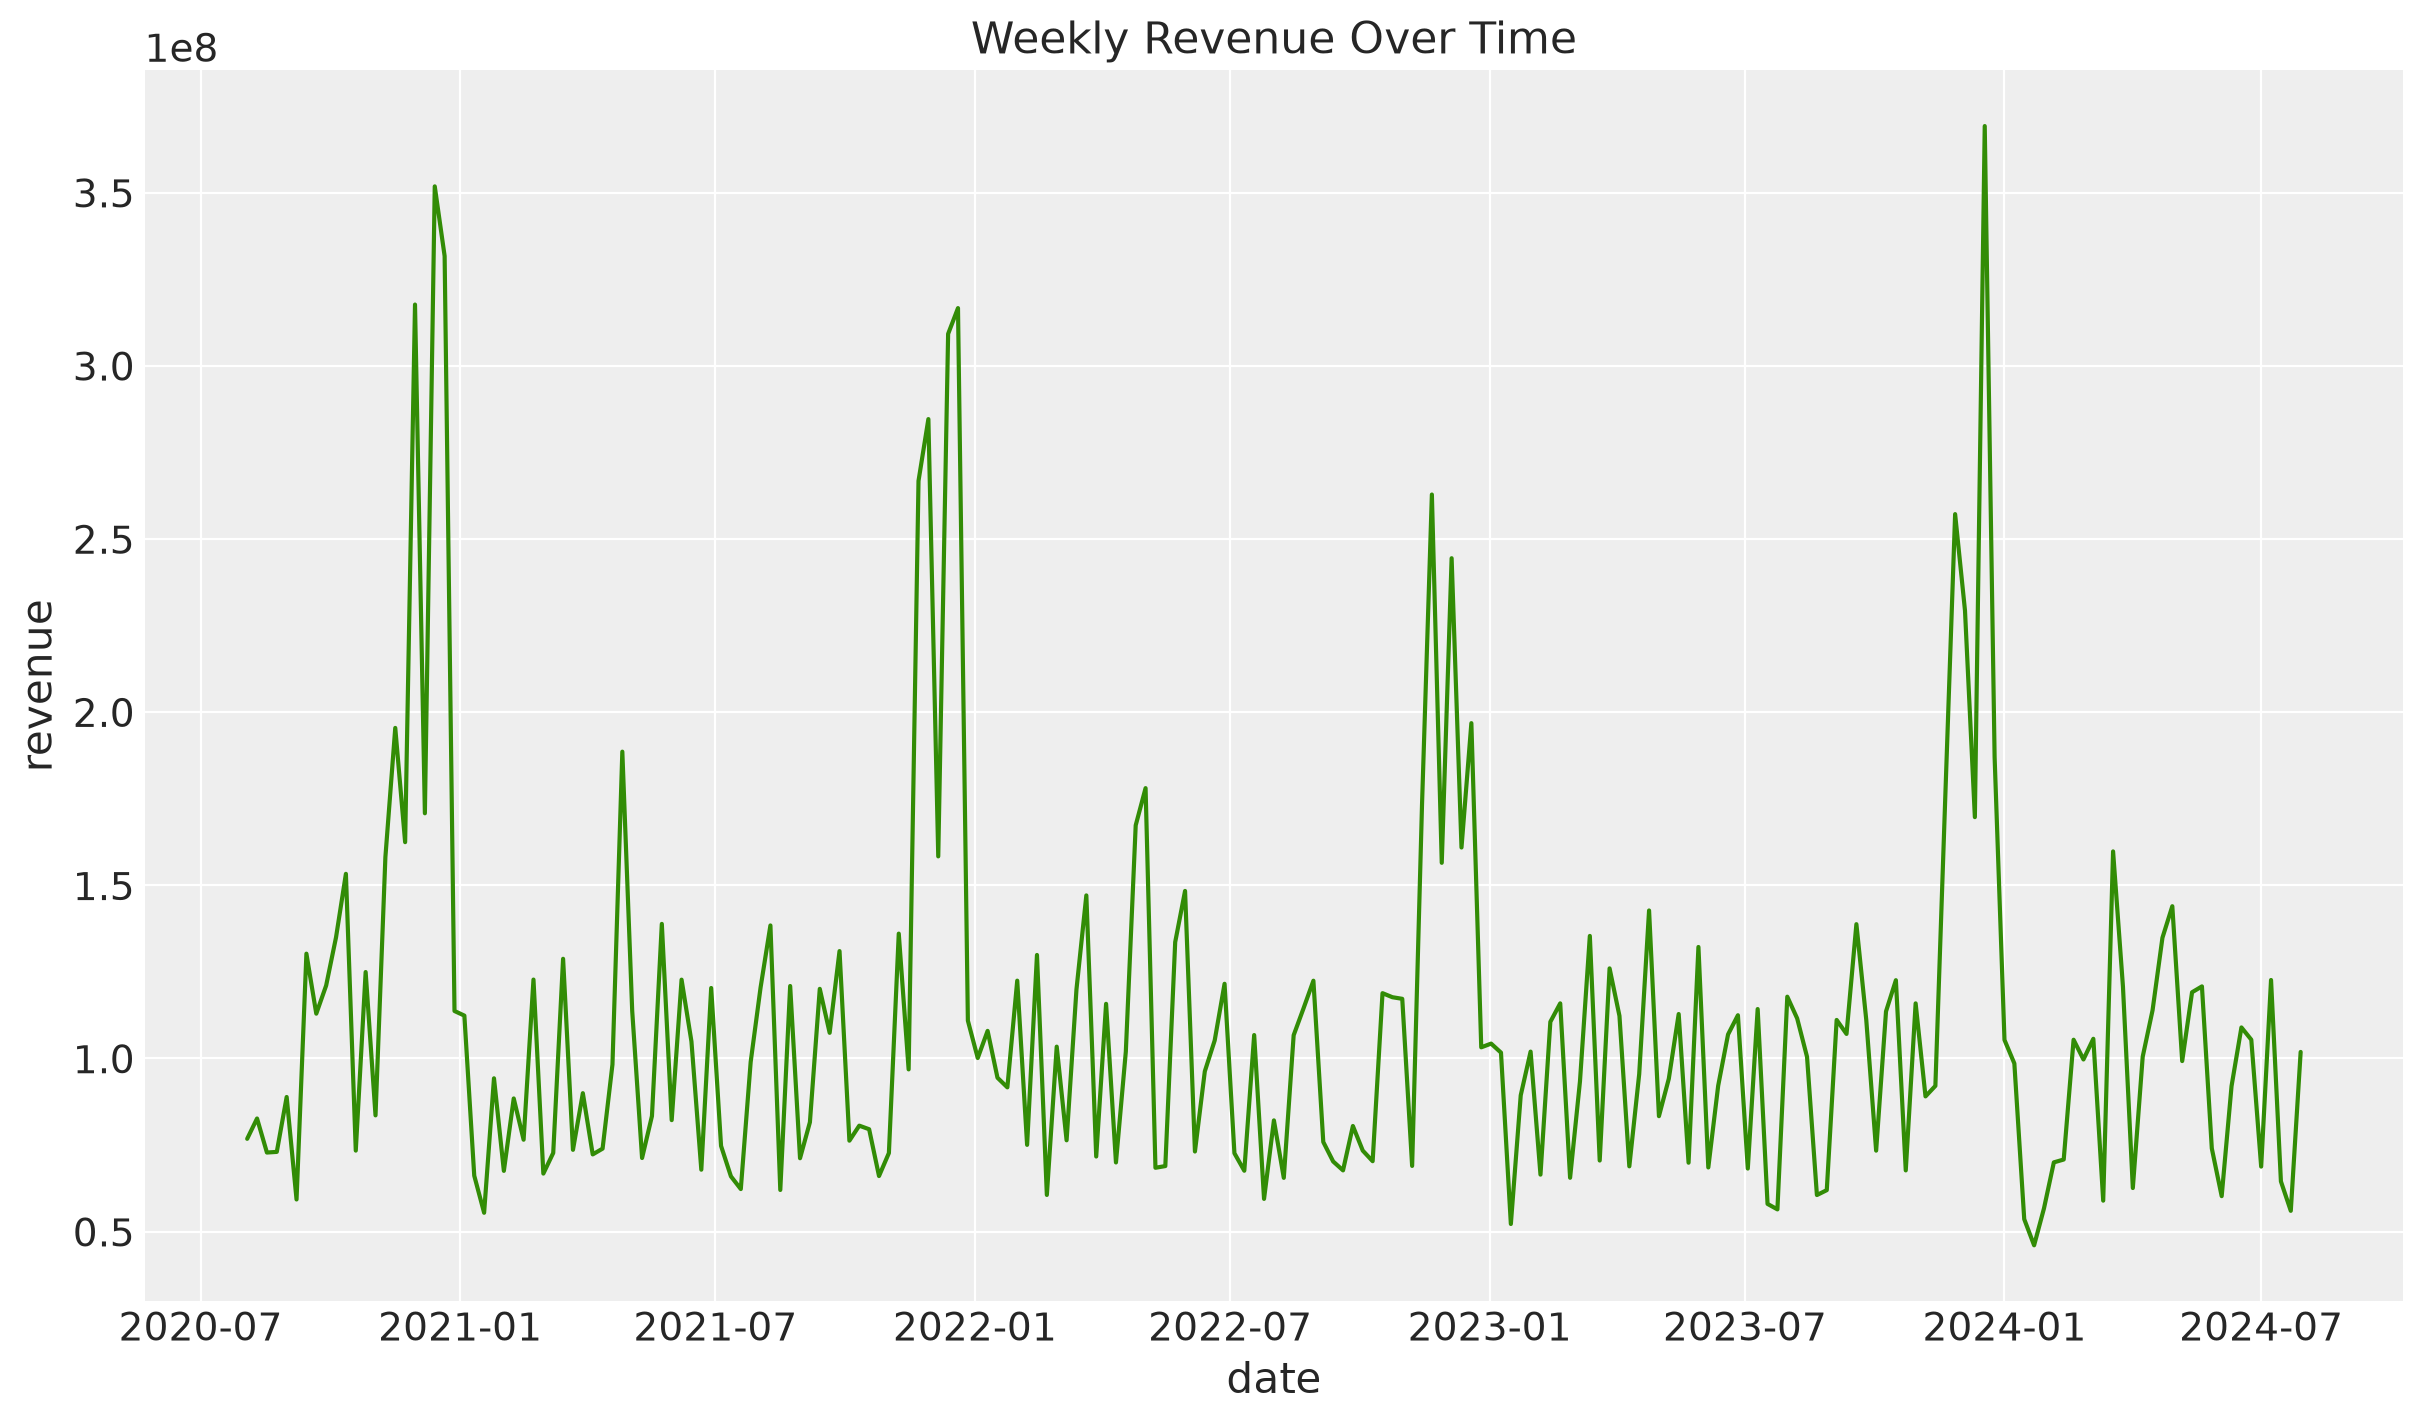

In [7]:
fig, ax = plt.subplots()
sns.lineplot(data=data_df, x=date_column, y=target_column, color="C2", ax=ax)
ax.set(title="Weekly Revenue Over Time", ylabel="revenue")

Text(0.5, 0.98, 'Weekly Spend per Channel')

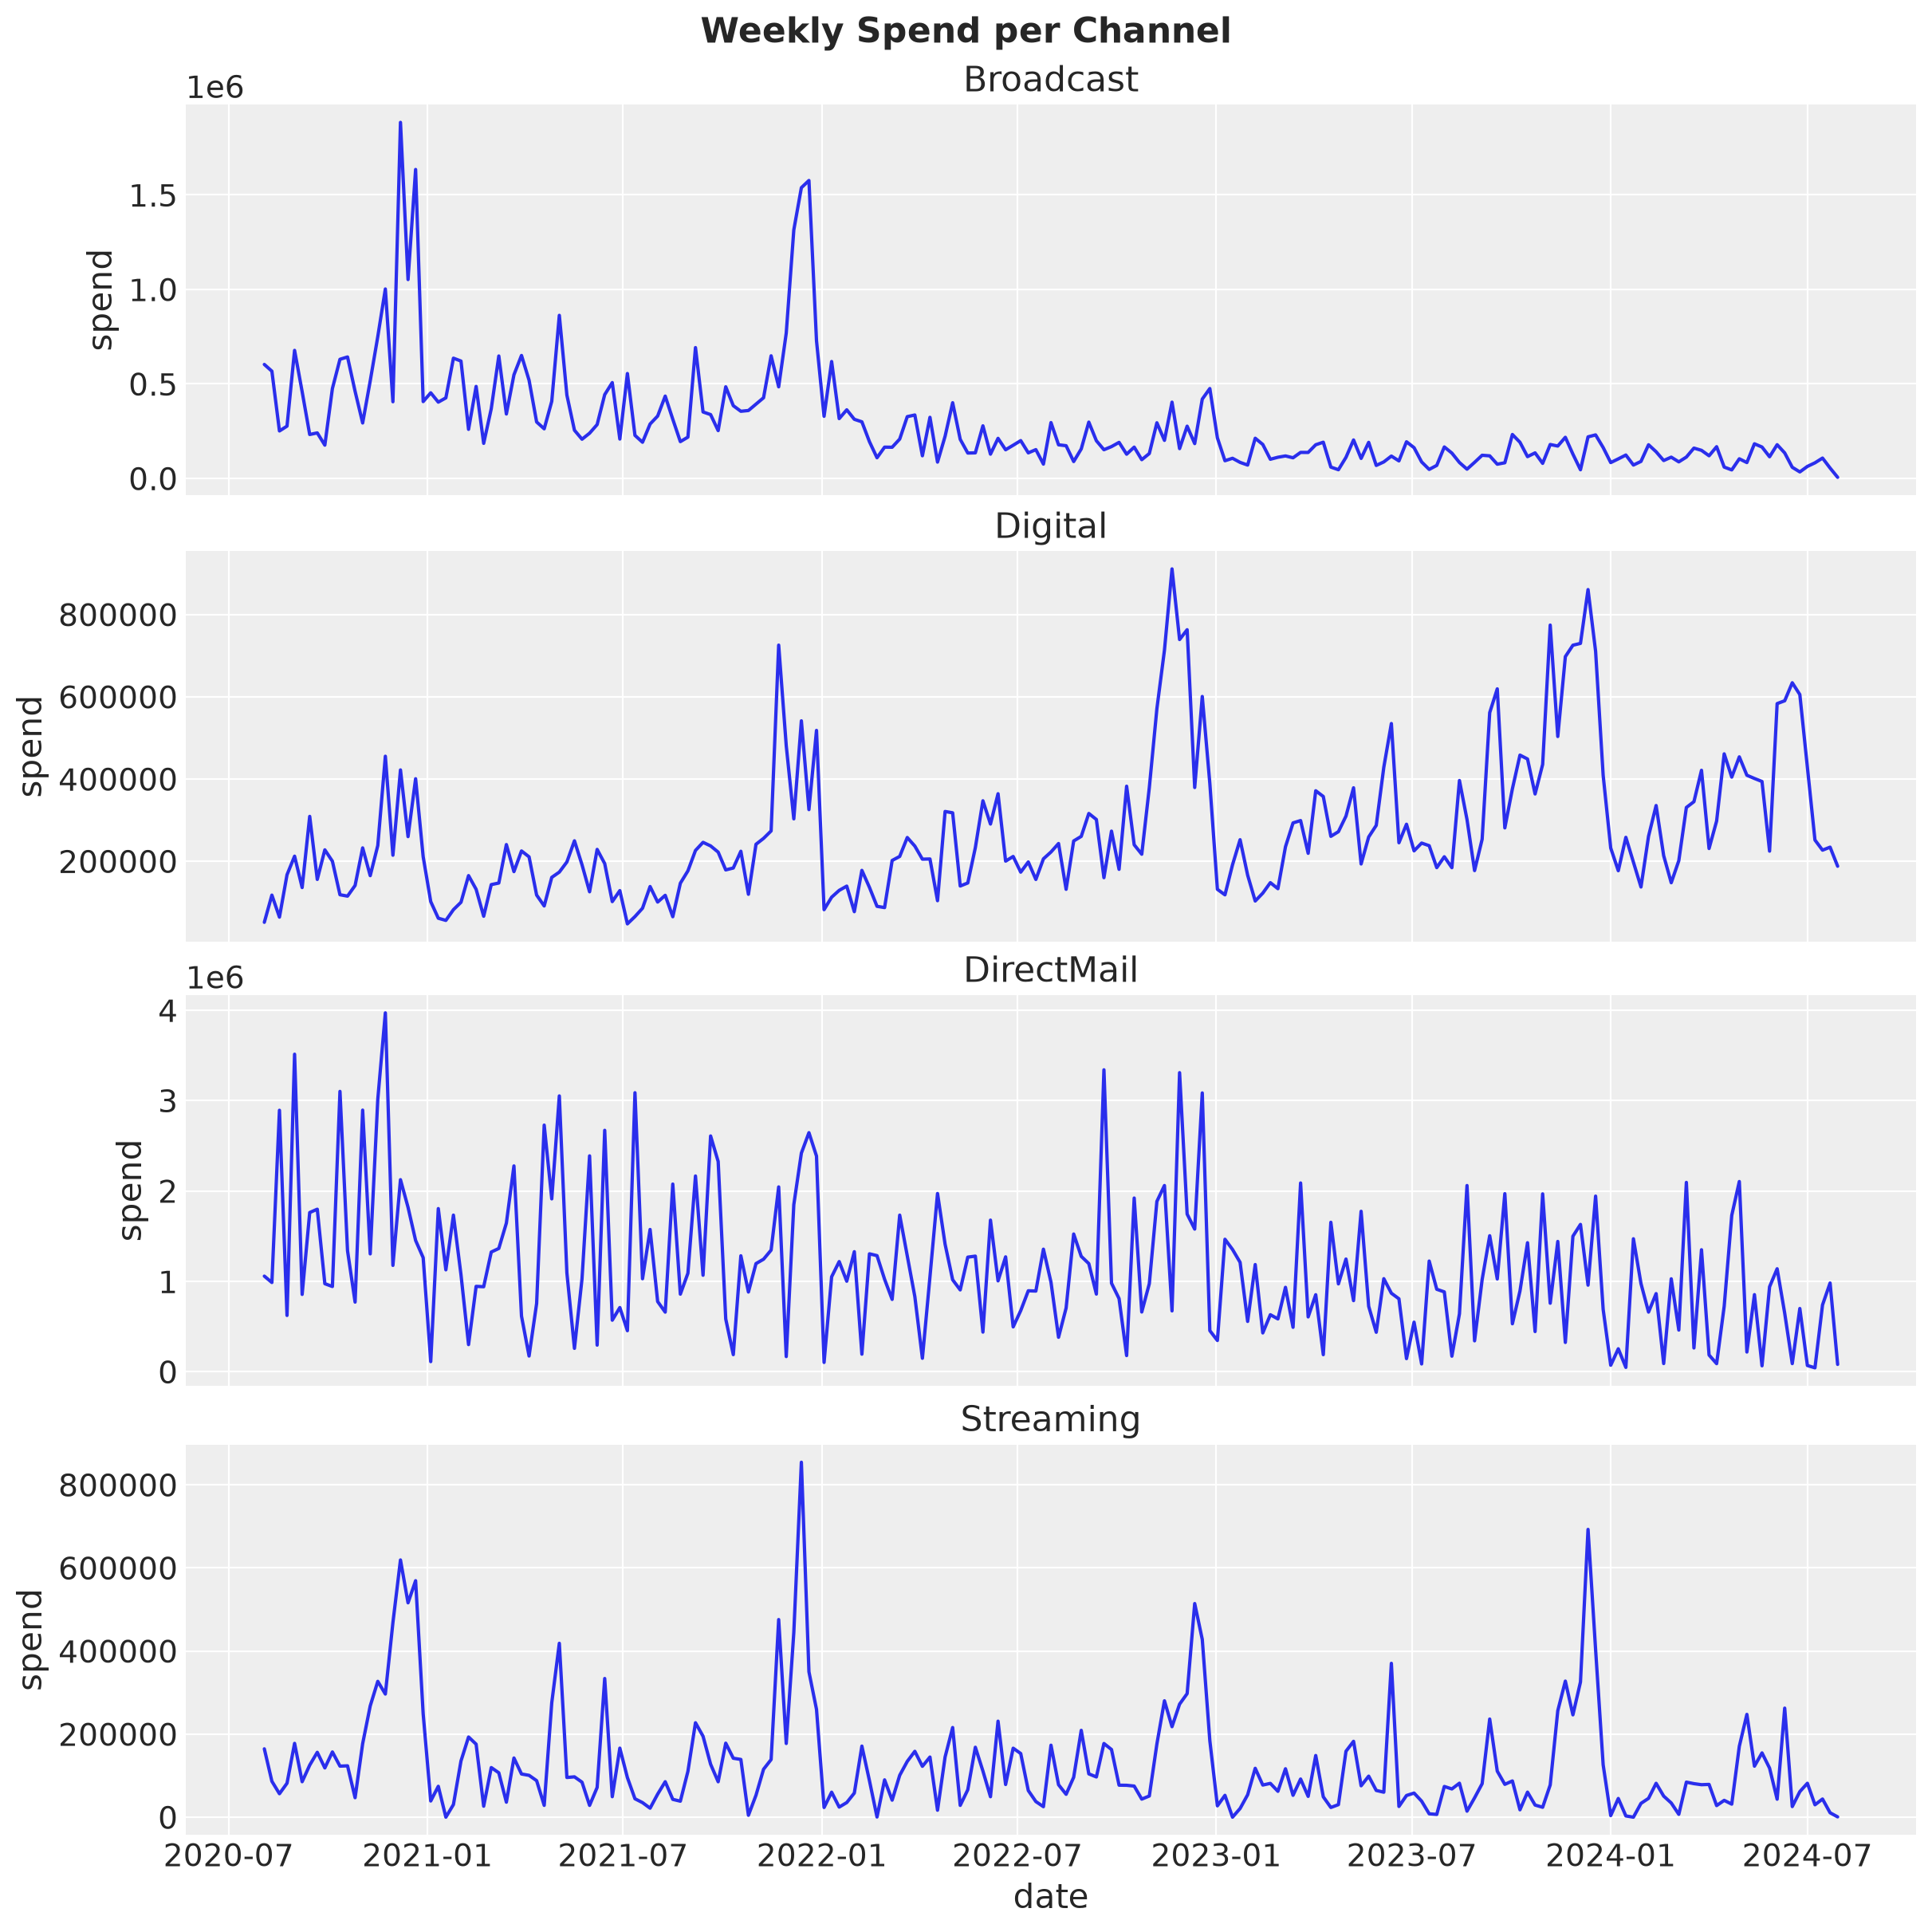

In [8]:
fig, axes = plt.subplots(nrows=len(channel_columns), ncols=1, figsize=(12, 12), sharex=True, layout="constrained")
for ax, channel in zip(axes, channel_columns, strict=True):
    sns.lineplot(data=data_df, x=date_column, y=channel, color="C0", ax=ax)
    ax.set(title=channel, ylabel="spend")
fig.suptitle("Weekly Spend per Channel", fontsize=16, fontweight="bold")


[Text(0.5, 1.0, 'Correlation Between Channels and Revenue')]

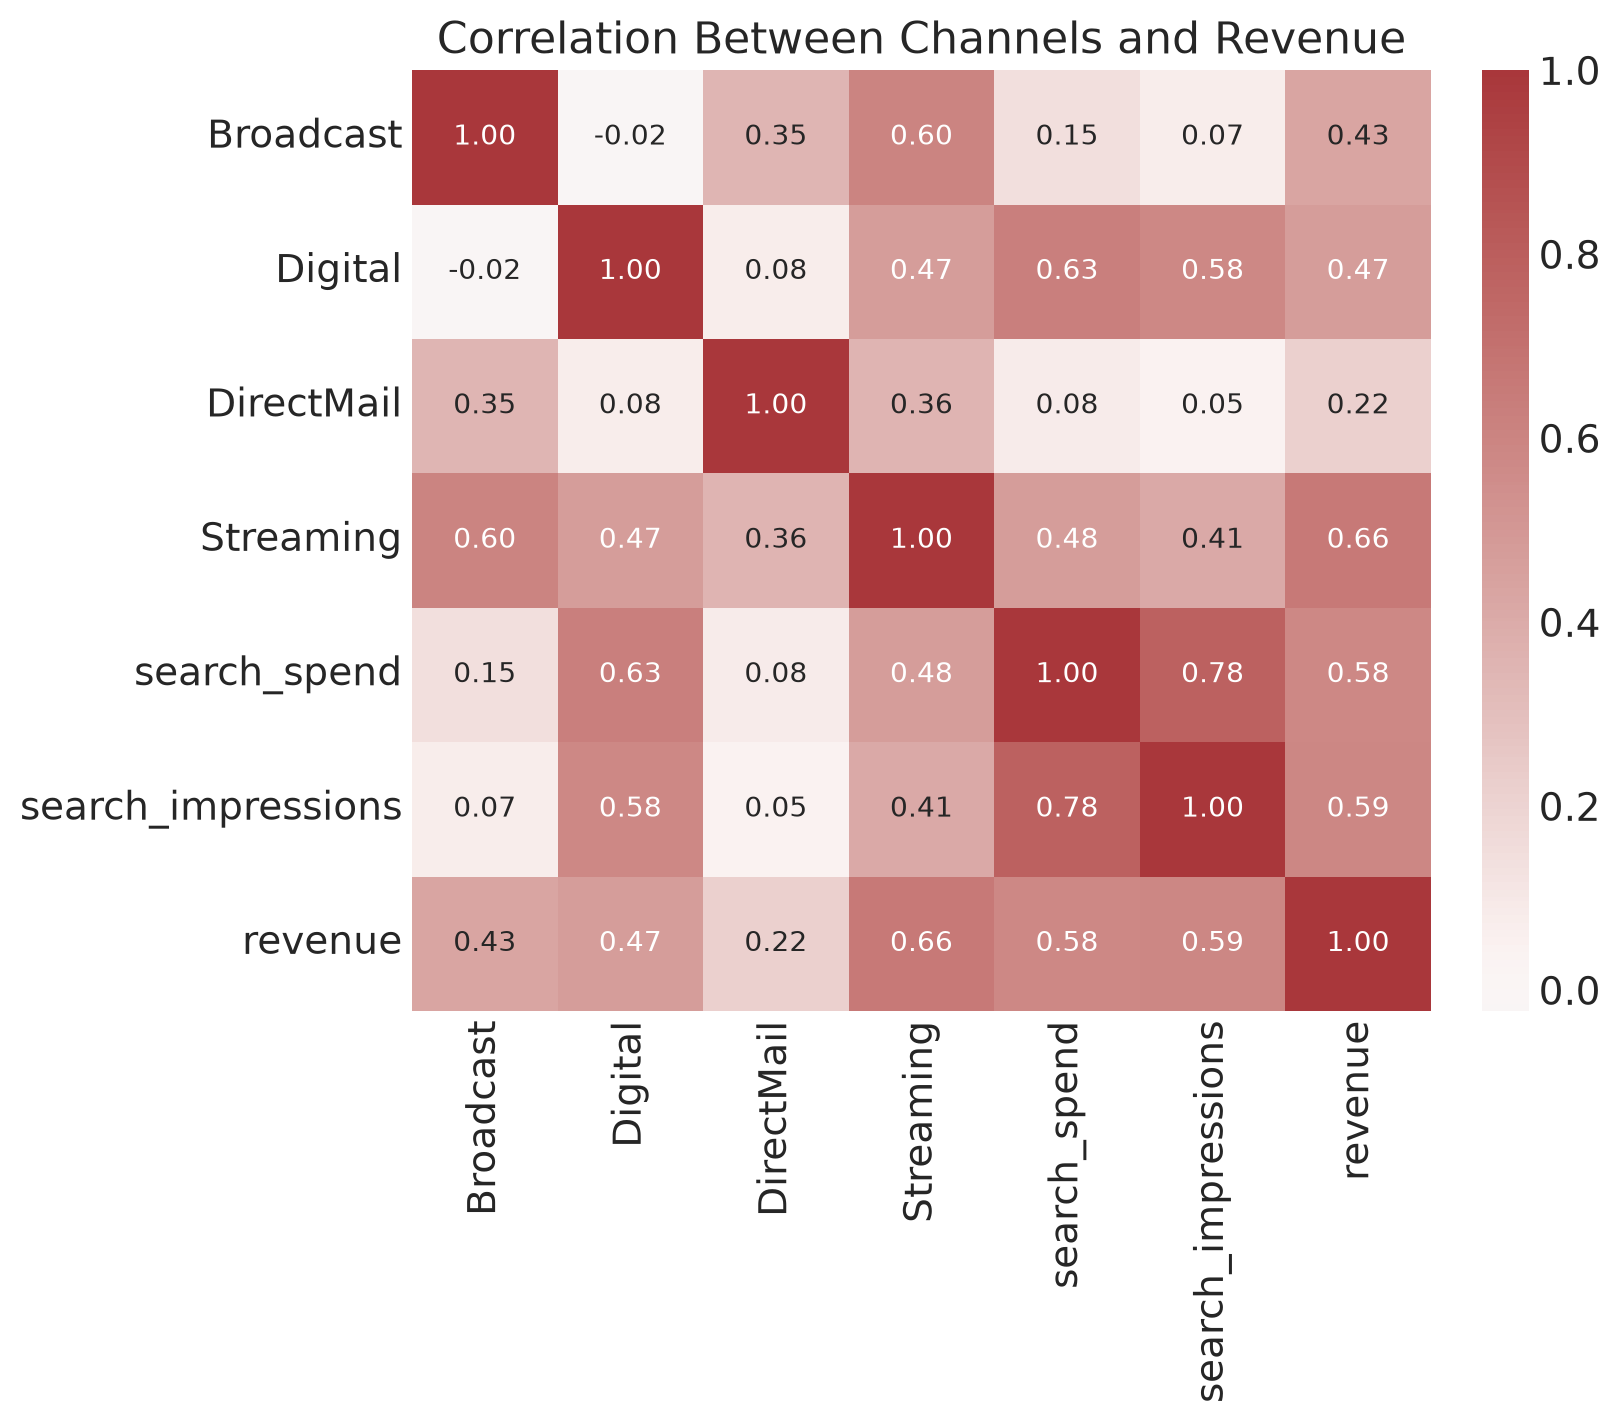

In [9]:
corr = data_df[[*channel_columns, "search_spend", "search_impressions", target_column]].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set(title="Correlation Between Channels and Revenue")


## Building the Search-as-Mediator Piece

`pymc-marketing` lets you plug a custom extra term into a model's mean, and that custom term is allowed to bring its own observed data with it. That's what we use to add the mediator behavior.

Here's what our custom piece does, step by step:

1. Takes the spend of `Broadcast` and `Streaming`, applies adstock and saturation to each (same as a normal channel would get), and adds them together into a hidden demand number.
2. Adds a scaled version of `search_spend` on top of that hidden demand.
3. Compares that combined total against the actual `search_impressions` we observed, treating the difference as noise.
4. Passes the combined total through one more adstock-and-saturation step and adds the result to revenue, alongside the direct contributions of every channel.

This way, the model estimates one set of numbers that has to explain both the search data and the revenue data at the same time, instead of fitting each separately.

**What the next cell defines.** `upper_dim` is the name (`"channel_upper"`) of a new PyMC coordinate used only inside this effect, separate from the model's regular `"channel"` dimension. `FunnelEffect` subclasses `pymc_marketing.mmm.additive_effect.DataVarMuEffect` and implements the four methods that interface requires:

- `to_dict`: serializes the effect's configuration (used if the model is saved/loaded).
- `incrementality_spec`: tells `pymc-marketing`'s incrementality module how much extra carryover (`l_max_lf` lags) the mediator's own adstock adds, so ROAS calculations later account for it.
- `create_data`: registers `upper_dim` as a model coordinate.
- `create_effect`: builds the actual PyMC graph — `demand`, `mediator`, the `TruncatedNormal` likelihood on `search_impressions`, and the returned `funnel_effect_contribution` term that gets added to the revenue mean.

None of this runs until the class is instantiated later, inside `make_funnel_effect`.



In [4]:
upper_dim = "channel_upper"


class FunnelEffect(DataVarMuEffect):
    """Upper-funnel spend -> latent demand -> search-harvested mediator -> revenue.

    The measurement coefficient on the mediator is fixed at one (times the
    impressions scale). This anchors the mediator scale and removes the
    likelihood-invariant ridge a free coefficient would create.
    """

    upper_channels: list[str]
    search_scale: float
    impressions_scale: float
    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize the effect."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_channels": self.upper_channels,
            "search_scale": self.search_scale,
            "impressions_scale": self.impressions_scale,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Opt in to incrementality, declaring the second adstock's reach."""
        return IncrementalitySpec(
            additional_carryover_lags=self.demand_transform.adstock.l_max
        )

    def create_data(self, mmm) -> None:
        """Register the funnel data variables and the upper-channel coordinate."""
        mmm.model.add_coord(upper_dim, self.upper_channels)
        super().create_data(mmm)

    def create_effect(self, mmm):
        """Build the mediator equation and the term it adds to the revenue mean."""
        model = mmm.model
        channel_index = [mmm.channel_columns.index(c) for c in self.upper_channels]
        upper = mmm.channel_data_scaled.isel(channel=channel_index).rename({"channel": upper_dim})
        upper_on_demand = self.upper_transform(upper, dim="date").sum(dim=upper_dim)

        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        demand = pmd.Deterministic(f"{self.prefix}_demand", baseline + upper_on_demand)

        lam = pmd.HalfNormal(f"{self.prefix}_lambda", sigma=0.5)
        mediator = pmd.Deterministic(
            f"{self.prefix}_mediator",
            demand + lam * model["search_spend"] / self.search_scale,
        )

        pmd.TruncatedNormal(
            f"{self.prefix}_search_impressions_likelihood",
            mu=self.impressions_scale * mediator,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_s", sigma=0.2 * self.impressions_scale),
            lower=0.0,
            observed=model["search_impressions"],
        )

        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(mediator, dim="date"),
        )


## Setting Up Both Models

Both models share the same basic settings: geometric adstock, logistic saturation, holiday controls, and yearly seasonality. The only structural difference is whether `search_spend` is a regular channel (standard model) or feeds into the mediator piece above (funnel model).

The funnel model needs its input data in a slightly different format so that `search_spend` and `search_impressions` travel along with it, including when we later ask it to predict on new data. We handle that with a small subclass below.

**What the next cell defines**, in the order it appears:

- `make_model_config(X, channels)`: returns the `model_config` dict shared by both models — a `Normal` intercept prior, a `HalfNormal` saturation-beta prior whose width scales with each channel's spend share, `Normal`/`Laplace` priors on the holiday and yearly-Fourier coefficients, and a `TruncatedNormal` likelihood.
- `l_max`, `l_max_lf`: the adstock carryover length (in weeks) for, respectively, every channel's direct path and the mediator's own path to revenue.
- `make_funnel_effect(search_scale, impressions_scale)`: builds one `FunnelEffect` instance, wiring up its two `MediaTransformation` objects (adstock + saturation, one for the upper-funnel-to-demand path, one for the mediator-to-revenue path).
- `FunnelMMM`: an `MMM` subclass that fixes two gotchas specific to funnel models. First, the model has to be *built* from an `xr.Dataset` rather than a plain `pd.DataFrame`, because `search_spend` and `search_impressions` only survive the data conversion as extra variables on a Dataset — fitting itself can still be handed the flat DataFrame. Second, any later call that predicts from a plain DataFrame (cross-validation, counterfactuals, holdout scoring) would otherwise silently drop those two columns and freeze them at their training-time values. Overriding `_posterior_predictive_data_transformation` reinstates them automatically, so every prediction path in this notebook keeps working with plain DataFrames, while a frame that's actually missing `search_spend`/`search_impressions` raises an error instead of failing silently.
- `make_funnel_dataset(X, y=None)`: a thin wrapper around `to_mmm_dataset` that always includes `funnel_vars` as `extra_vars`.
- `make_funnel_mmm(X)`: constructs the funnel-aware model — a `FunnelMMM` over `channel_columns` only, with the `FunnelEffect` attached via `add_mu_effect`.
- `make_standard_mmm(X)`: constructs the standard model — a plain `MMM` whose `channel_columns` is `channel_columns` plus `"search_spend"`, so the mediator never enters the picture.



In [5]:
def make_model_config(X: pd.DataFrame, channels: list[str]) -> dict:
    """Build a model configuration with spend-share prior widths from X."""
    spend_shares = (X[channels].sum().reindex(channels) / X[channels].sum().sum()).to_numpy()
    return {
        "intercept": Prior("Normal", mu=0.2, sigma=0.05),
        "saturation_beta": Prior(
            "HalfNormal", sigma=xr.DataArray(spend_shares, dims="channel"), dims="channel"
        ),
        "gamma_control": Prior("Normal", mu=0, sigma=1, dims="control"),
        "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
        "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)),
    }


l_max = 6  # direct-path adstock
l_max_lf = 6  # mediator -> revenue adstock


def make_funnel_effect(search_scale: float, impressions_scale: float) -> FunnelEffect:
    """Build the funnel effect with its two media transformations."""
    return FunnelEffect(
        data_vars=funnel_vars,
        prefix="funnel",
        upper_channels=upper_channels,
        search_scale=search_scale,
        impressions_scale=impressions_scale,
        upper_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max, prefix="adstock_uf", priors={"alpha": Prior("Beta", alpha=2, beta=3, dims=upper_dim)}
            ),
            saturation=LogisticSaturation(
                prefix="sat_uf",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0, dims=upper_dim),
                    "beta": Prior("HalfNormal", sigma=1.0, dims=upper_dim),
                },
            ),
            adstock_first=True,
            dims=(upper_dim,),
        ),
        demand_transform=MediaTransformation(
            adstock=GeometricAdstock(l_max=l_max_lf, prefix="adstock_lf", priors={"alpha": Prior("Beta", alpha=2, beta=3)}),
            saturation=LogisticSaturation(
                prefix="sat_lf",
                priors={"lam": Prior("Gamma", mu=1.5, sigma=0.5), "beta": Prior("HalfNormal", sigma=1.0)},
            ),
            adstock_first=True,
            dims=(),
        ),
    )


class FunnelMMM(MMM):
    """MMM that carries the funnel data variables through DataFrame conversion."""

    def _posterior_predictive_data_transformation(self, X, y=None, include_last_observations: bool = False):
        if isinstance(X, pd.DataFrame):
            missing = [var for var in funnel_vars if var not in X.columns]
            if missing:
                raise ValueError(f"funnel columns missing from prediction frame: {missing}")
            X = to_mmm_dataset(
                X, y, date_column=self.date_column, dims=self.dims,
                channel_columns=self.channel_columns, control_columns=self.control_columns,
                target_column=self.target_column, extra_vars=funnel_vars,
            )
            y = None
        return super()._posterior_predictive_data_transformation(X, y=y, include_last_observations=include_last_observations)


def make_funnel_dataset(X: pd.DataFrame, y: pd.Series | None = None) -> xr.Dataset:
    """Convert the flat frame to the Dataset the funnel model builds from."""
    return to_mmm_dataset(
        X, y, date_column=date_column, channel_columns=channel_columns,
        control_columns=control_columns, target_column=target_column, extra_vars=funnel_vars,
    )


def make_funnel_mmm(X: pd.DataFrame) -> FunnelMMM:
    """Build the funnel-aware MMM with scales and prior widths computed from X."""
    mmm = FunnelMMM(
        model_config=make_model_config(X, channel_columns),
        target_column=target_column,
        date_column=date_column,
        adstock=GeometricAdstock(l_max=l_max),
        saturation=LogisticSaturation(),
        time_varying_intercept=True,
        channel_columns=channel_columns,
        control_columns=control_columns,
        yearly_seasonality=5,
    )
    mmm.add_mu_effect(
        make_funnel_effect(
            search_scale=float(X["search_spend"].max()),
            impressions_scale=float(X["search_impressions"].max()),
        )
    )
    return mmm


def make_standard_mmm(X: pd.DataFrame) -> MMM:
    """Build the standard MMM: search_spend as an ordinary channel."""
    channels = [*channel_columns, "search_spend"]
    return MMM(
        model_config=make_model_config(X, channels),
        target_column=target_column,
        date_column=date_column,
        adstock=GeometricAdstock(l_max=l_max),
        saturation=LogisticSaturation(),
        channel_columns=channels,
        time_varying_intercept=True,
        control_columns=control_columns,
        yearly_seasonality=5,
    )


## Fitting Both Models

We fit both models on the full history:

- The **standard model** puts `search_spend` next to the other four channels as just another channel.
- The **funnel model** keeps the same four direct channels, and adds the mediator piece so the two upper-funnel channels also get credit for the search demand they create.

Both use the same settings otherwise. Fitting both models (and the holdout refits later on) takes a while — feel free to lower the draws/tuning numbers below for a quicker test run.


In [6]:
sample_kwargs = dict(chains=4, tune=1_000, draws=1_000, target_accept=0.97, random_seed=rng)

standard = make_standard_mmm(X)
standard.build_model(X, y)
standard.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
standard.fit(X, y, **sample_kwargs)
standard.sample_posterior_predictive(X, random_seed=rng);


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 131 seconds.


Output()

Sampling: [y]


Output()

In [7]:
funnel = make_funnel_mmm(X)
funnel.build_model(X=make_funnel_dataset(X, y))
funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)
funnel.fit(X=X, y=y, **sample_kwargs)
funnel.sample_posterior_predictive(X, random_seed=rng);


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, adstock_lf_alpha, funnel_lambda, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, funnel_sigma_s]


Output()

/Users/Office/.conda/envs/pymc-marketing-1.0/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 233 seconds.


Output()

Sampling: [funnel_search_impressions_likelihood, y]


Output()

## Checking the Models Sampled Properly

Before looking at any results, it's worth checking that the model fitting actually went well for both models.

**What the next cell does.** For each of `standard` and `funnel`, it reads `idata["sample_stats"]["diverging"]` (the count of divergent NUTS transitions — ideally 0) and the maximum `r_hat` across all parameters from `az.summary(...)` (values well above 1.01 signal chains that haven't converged to the same posterior).



In [14]:
for label, m in [("Standard", standard), ("Funnel", funnel)]:
    divergences = int(m.idata["sample_stats"]["diverging"].sum())
    max_rhat = float(az.summary(m.idata)["r_hat"].max())
    print(f"{label:10s} | divergences: {divergences:3d} | max r-hat: {max_rhat:.3f}")


/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnos

Standard   | divergences:   1 | max r-hat: 1.007


/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/Office/.local/lib/python3.12/site-packages/arviz_stats/base/diagnos

Funnel     | divergences:   0 | max r-hat: 1.005


## Does Each Model Reproduce What We Actually Saw?

The funnel model has to explain two things at once: `revenue`, and the `search_impressions` numbers it uses as a stand-in for hidden demand. We check both.

**What the next two cells do.** The first defines `hdi_bounds(da, prob)`, a small helper that calls `az.hdi` and returns the lower/upper bound `DataArray`s separately (handling the case where `az.hdi` wraps a single variable in a `Dataset`). It then plots, for each of `standard` and `funnel`, the posterior mean and `HDI_PROB` band of `y_original_scale` against the actually observed `revenue` series `y`.

The second cell does the same for the funnel model's second observed variable, `funnel_search_impressions_likelihood` — the posterior predictive for `search_impressions` — again comparing the posterior mean and HDI band against what was actually observed.



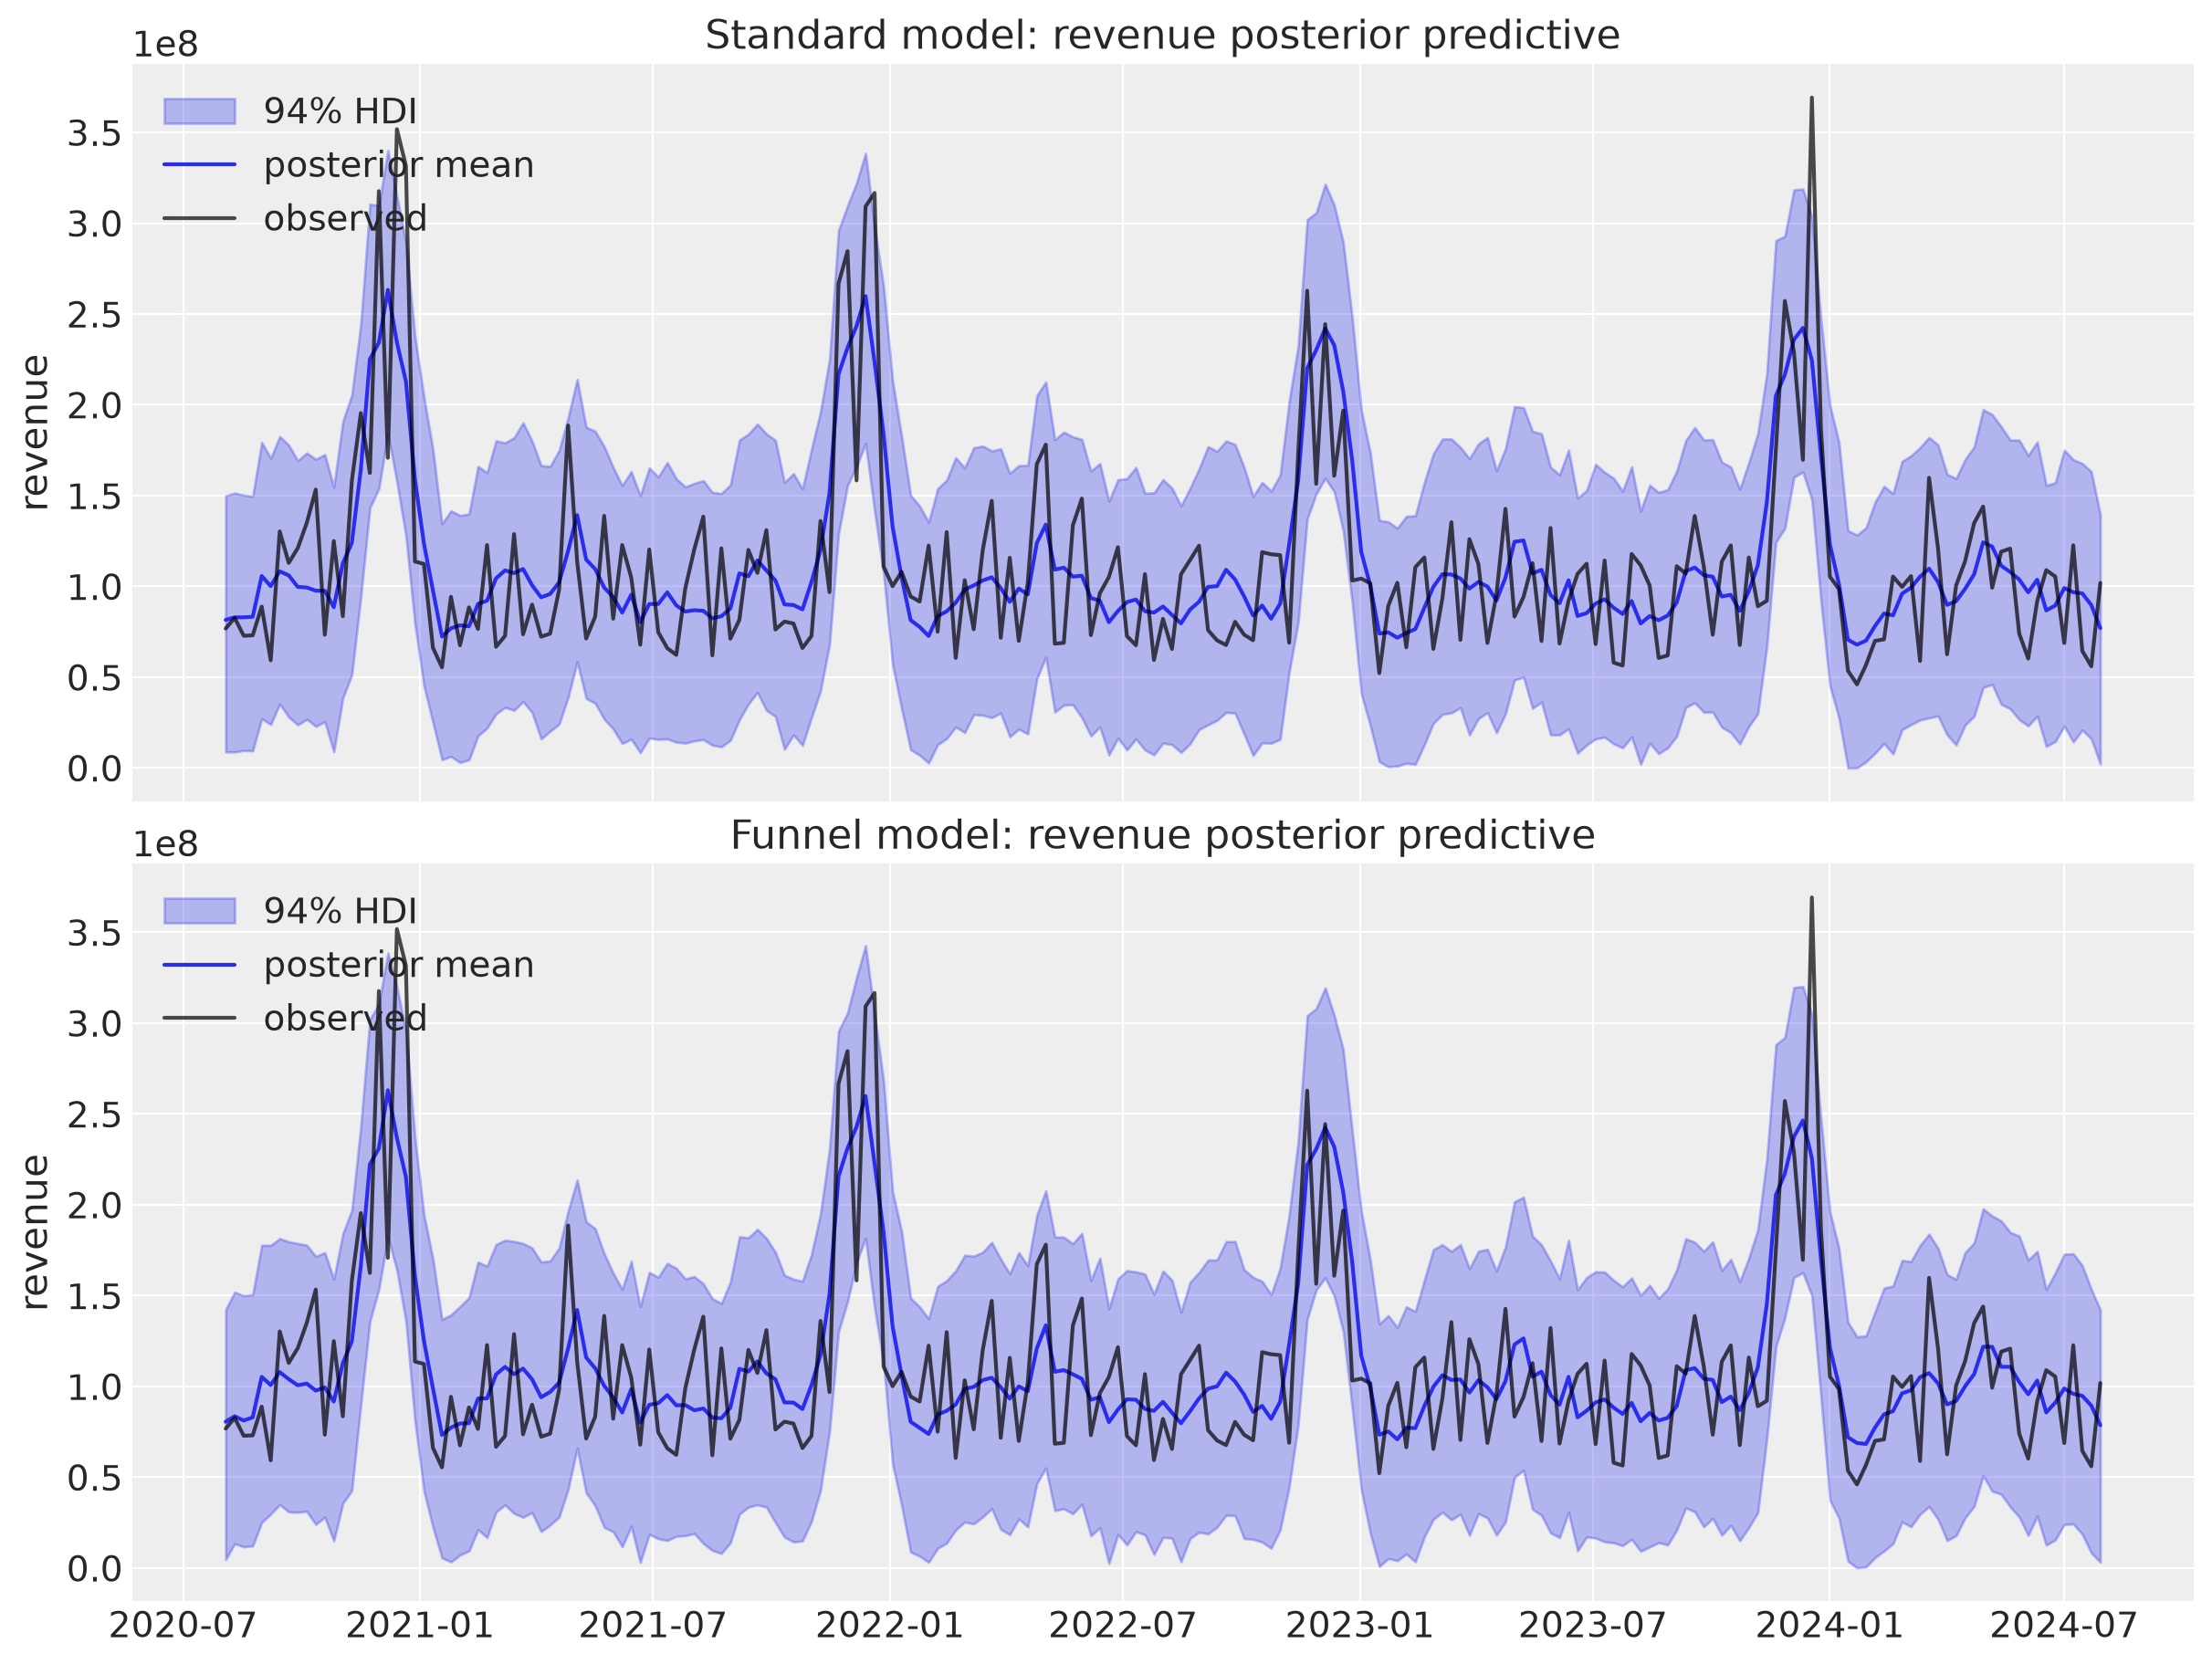

In [15]:
def hdi_bounds(da, prob: float = HDI_PROB):
    """Return (lower, upper) HDI DataArrays for a posterior DataArray."""
    h = az.hdi(da, prob=prob)
    if isinstance(h, xr.Dataset):
        h = h[next(iter(h.data_vars))]
    return h.sel(ci_bound="lower"), h.sel(ci_bound="upper")


fig, axes = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, layout="constrained")
for ax, (label, m) in zip(axes, [("Standard", standard), ("Funnel", funnel)], strict=True):
    pp = m.idata.posterior_predictive["y_original_scale"]
    mean = pp.mean(dim=[d for d in pp.dims if d != "date"]).to_numpy()
    lo, hi = hdi_bounds(pp)
    ax.fill_between(data_df[date_column], lo, hi, alpha=0.3, color="C0", label=f"{HDI_PROB:.0%} HDI")
    ax.plot(data_df[date_column], mean, color="C0", label="posterior mean")
    ax.plot(data_df[date_column], y, color="black", alpha=0.7, label="observed")
    ax.set(title=f"{label} model: revenue posterior predictive", ylabel="revenue")
    ax.legend(loc="upper left")


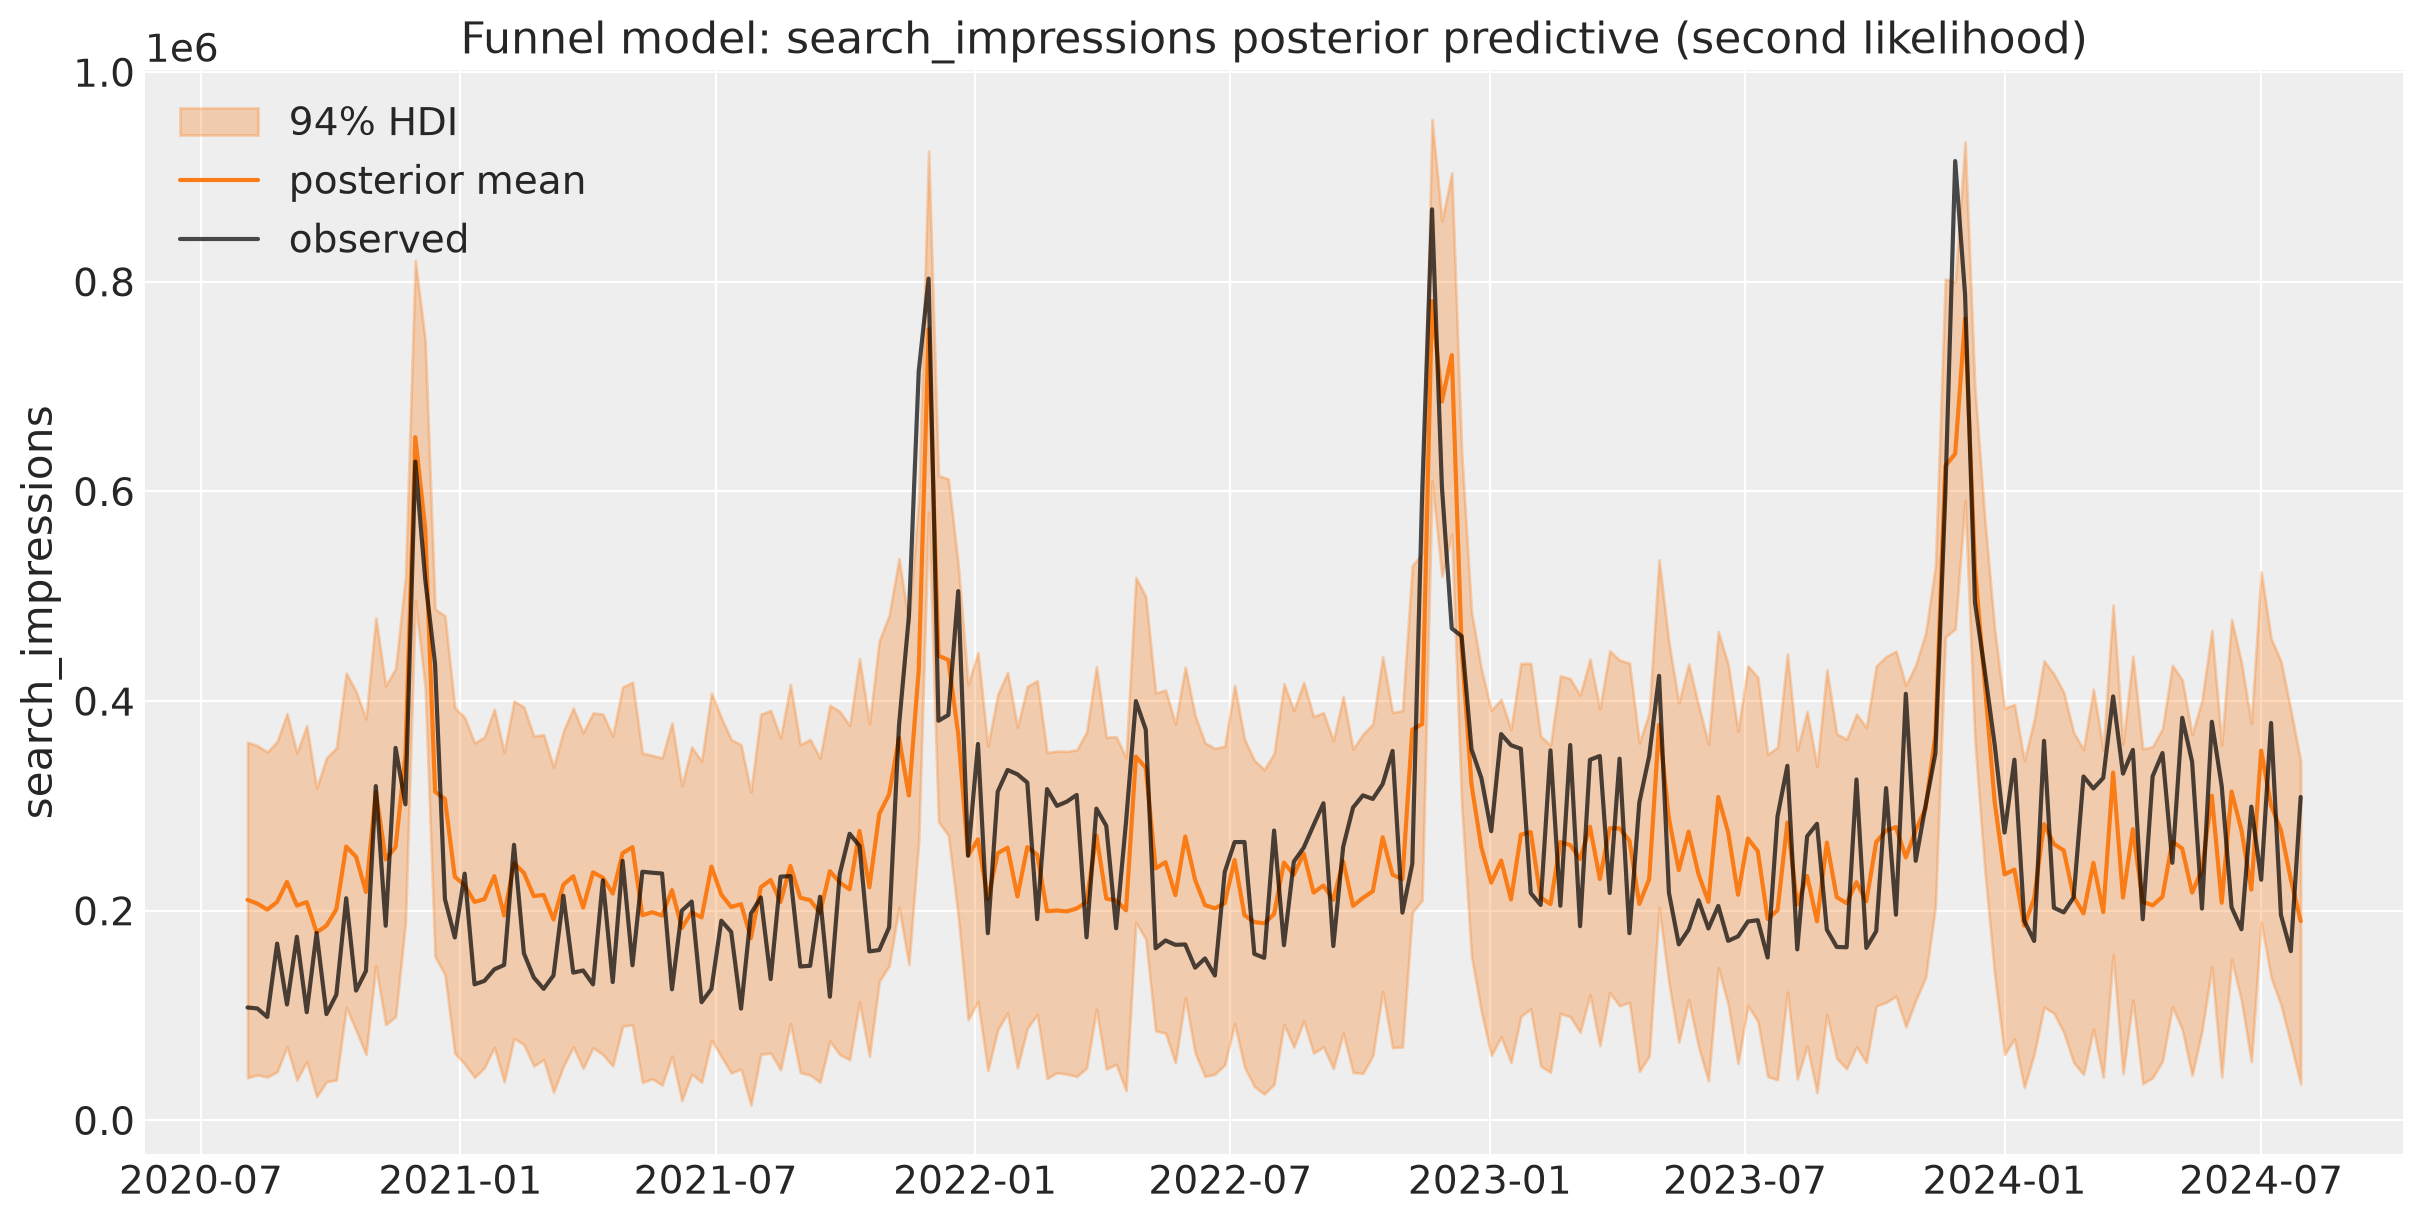

In [16]:
impressions_pp = funnel.idata.posterior_predictive["funnel_search_impressions_likelihood"]
impressions_mean = impressions_pp.mean(dim=[d for d in impressions_pp.dims if d != "date"]).to_numpy()
impressions_lo, impressions_hi = hdi_bounds(impressions_pp)

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(data_df[date_column], impressions_lo, impressions_hi, alpha=0.3, color="C1", label=f"{HDI_PROB:.0%} HDI")
ax.plot(data_df[date_column], impressions_mean, color="C1", label="posterior mean")
ax.plot(data_df[date_column], data_df["search_impressions"], color="black", alpha=0.7, label="observed")
ax.legend(loc="upper left")
ax.set(title="Funnel model: search_impressions posterior predictive (second likelihood)", ylabel="search_impressions");


## Splitting Upper-Funnel Credit into Direct and Indirect Parts

Only the funnel model can answer this: out of all the revenue we attribute to `Broadcast` and `Streaming`, how much comes from their direct effect, and how much comes from the extra search demand they generate? To isolate the indirect part, we compare the mediator's contribution as fitted against what it would look like if upper-funnel spend had been zero the whole time — the difference is the part that's actually caused by upper-funnel spend, rather than baseline demand or search's own spend.

**What the next two cells do.** `X_zero` is a copy of `X` with `upper_channels` spend set to 0; `cf` is the funnel model's posterior-predictive `funnel_effect_contribution_original_scale` under that counterfactual, which isolates whatever indirect contribution is *not* caused by upper-funnel spend. From there:

- `direct_post`: the upper-funnel channels' own `channel_contribution_original_scale`, summed across `upper_channels`.
- `indirect_post`: the fitted mediator contribution minus the zero-spend counterfactual (`cf`) — the part of the indirect path actually attributable to upper-funnel spend.
- `total_post`: `direct_post + indirect_post`, the funnel model's full estimate of upper-funnel value.

The second cell plots all three as time series with `HDI_PROB` bands, and prints `indirect_share`, the posterior-mean fraction of `total_post` that comes from the indirect path.



In [17]:
X_zero = X.copy()
X_zero[upper_channels] = 0.0  # counterfactual: no upper-funnel spend at all

cf = funnel.sample_posterior_predictive(
    make_funnel_dataset(X_zero),
    extend_idata=False,
    combined=False,
    var_names=["funnel_effect_contribution_original_scale"],
    random_seed=rng,
)

direct_post = (
    funnel.idata.posterior["channel_contribution_original_scale"]
    .sel(channel=upper_channels)
    .sum(dim="channel")
)
indirect_post = (
    funnel.idata.posterior["funnel_effect_contribution_original_scale"]
    - cf["funnel_effect_contribution_original_scale"]
)
total_post = direct_post + indirect_post


/Users/Office/.conda/envs/pymc-marketing-1.0/lib/python3.12/site-packages/pytensor/tensor/type.py:684: RuntimeWarning: invalid value encountered in divide
  f"numpy allclose failed for abs_err {np.max(abs(a - b))} and rel_err {np.max(abs(a - b) / (abs(a) + abs(b)))}"
Sampling: []


Output()

Indirect share of the upper-funnel effect (posterior mean): 10.0%


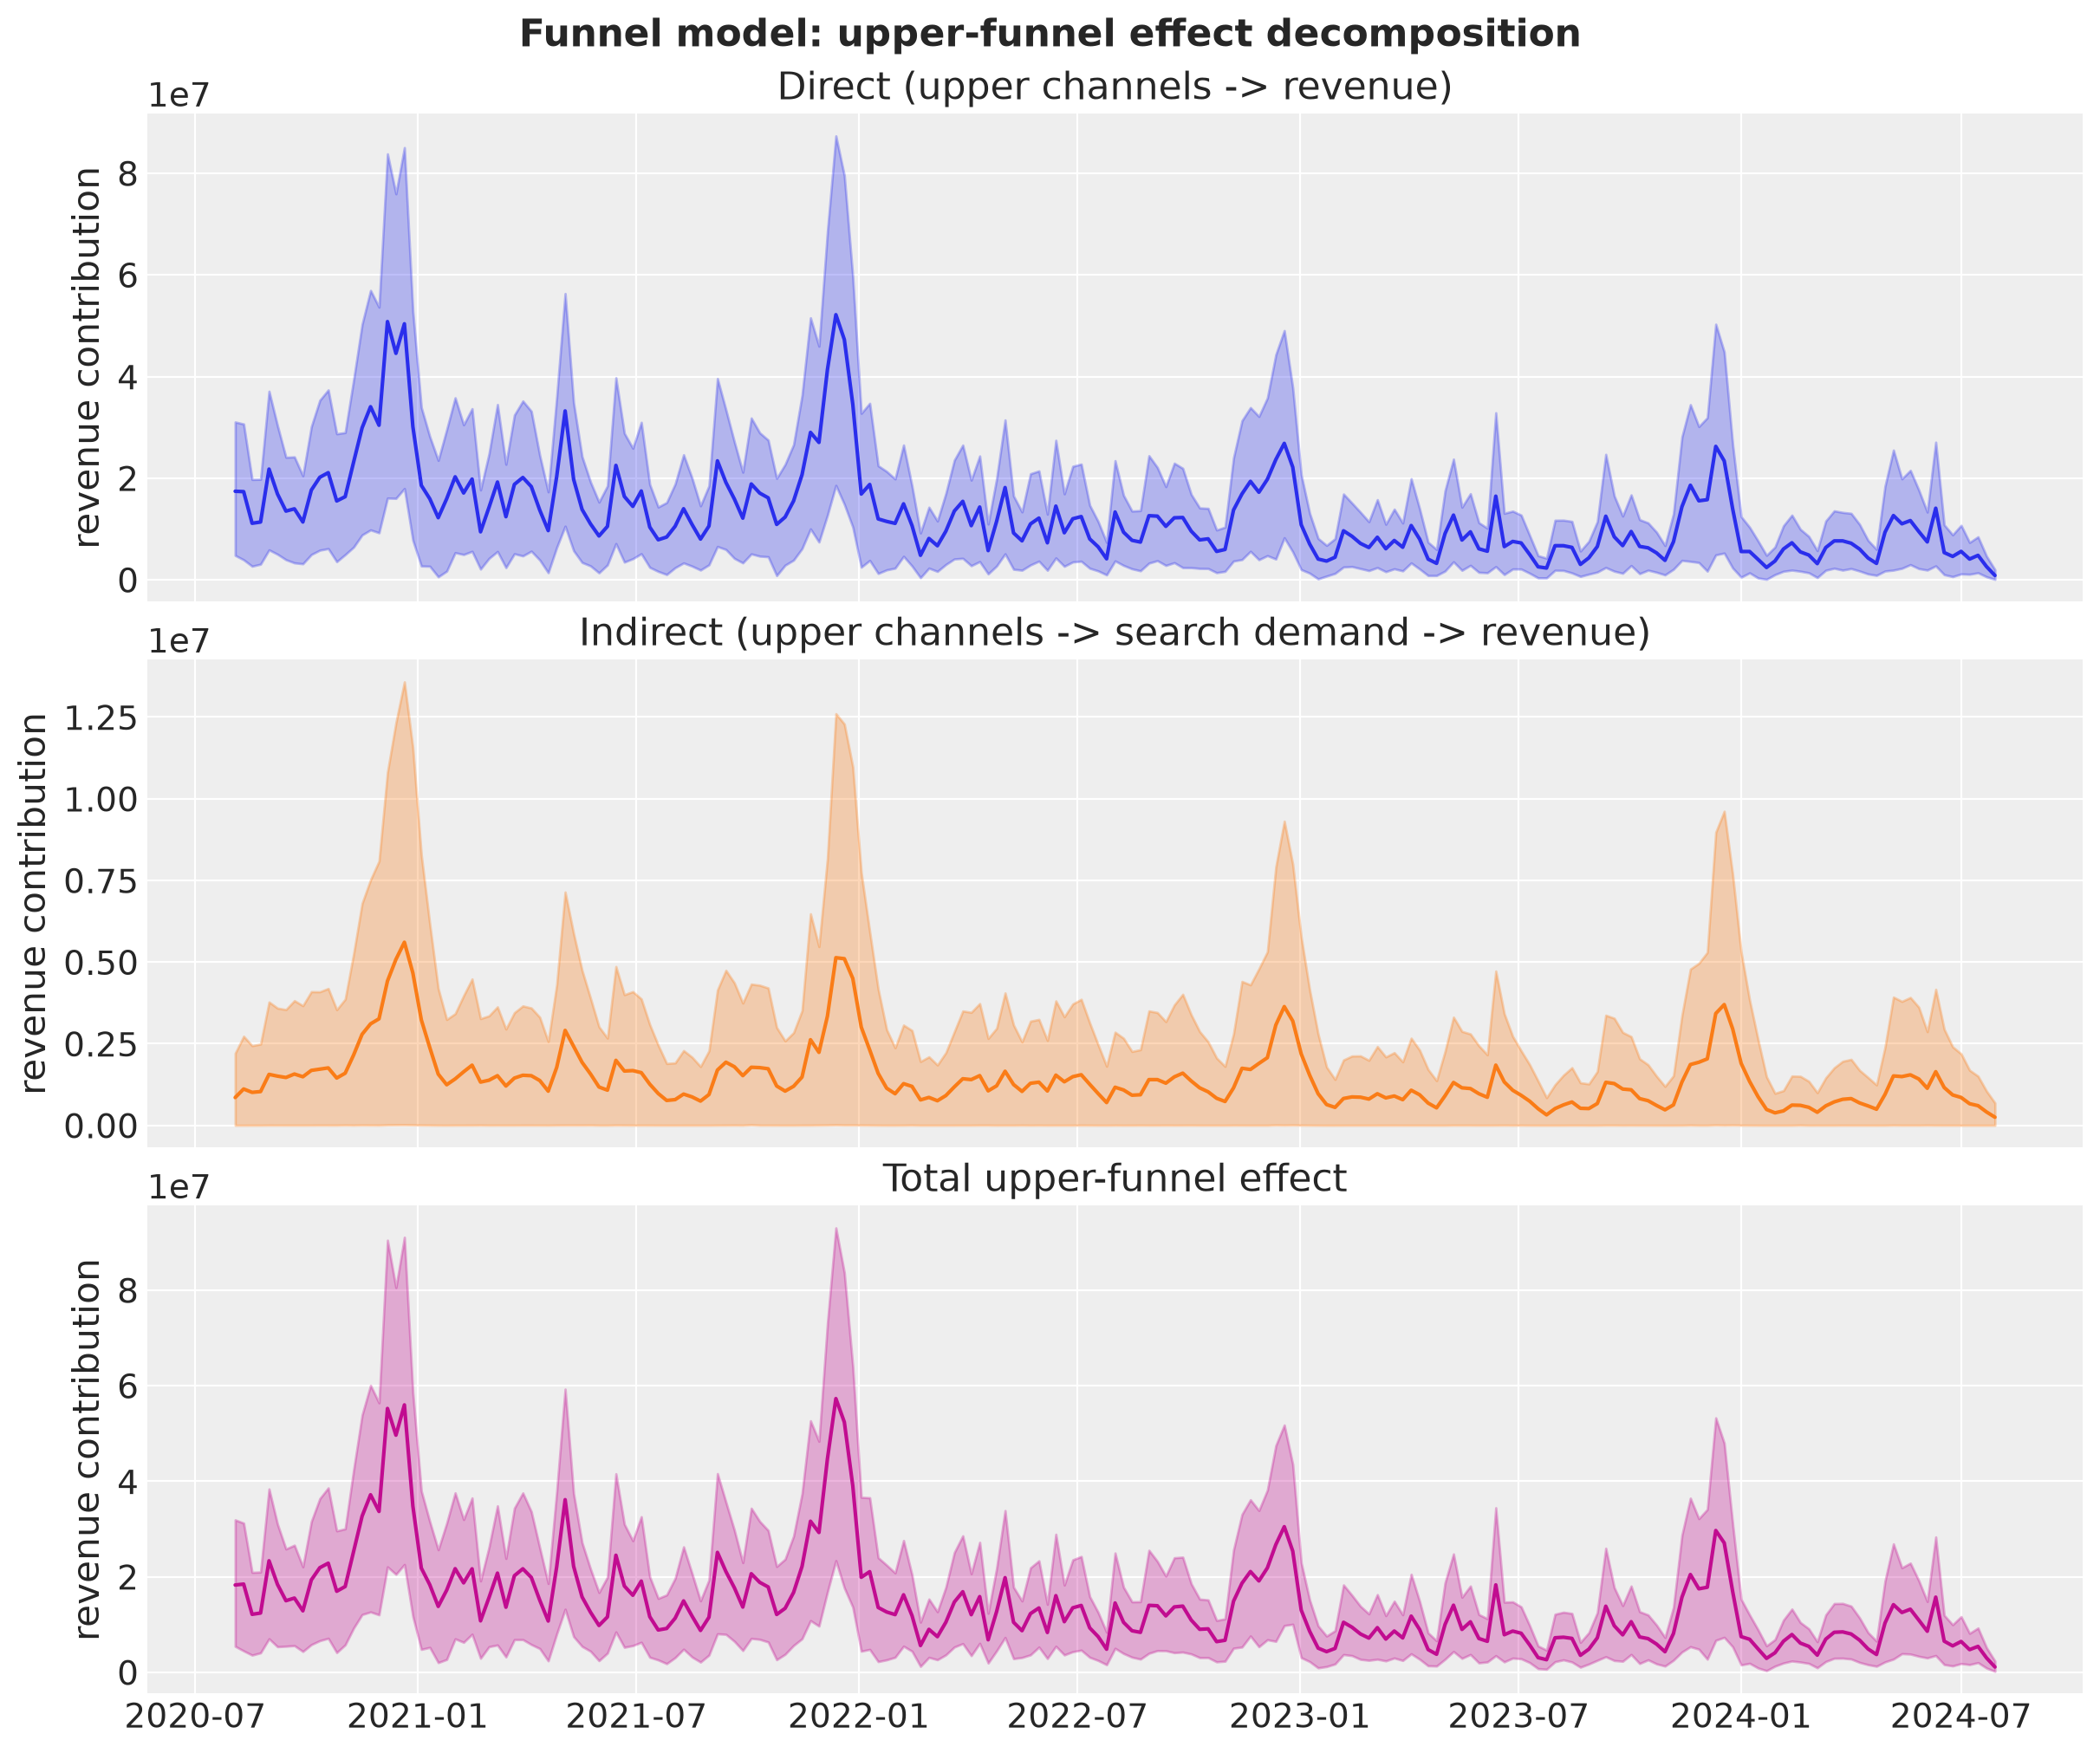

In [18]:
fig, axes = plt.subplots(nrows=3, figsize=(12, 10), sharex=True, layout="constrained")
for ax, post, title, color in [
    (axes[0], direct_post, "Direct (upper channels -> revenue)", COLOR_DIRECT),
    (axes[1], indirect_post, "Indirect (upper channels -> search demand -> revenue)", COLOR_INDIRECT),
    (axes[2], total_post, "Total upper-funnel effect", "C3"),
]:
    mean = post.mean(dim=["chain", "draw"]).to_numpy()
    lo, hi = hdi_bounds(post)
    ax.fill_between(data_df[date_column], lo, hi, alpha=0.3, color=color)
    ax.plot(data_df[date_column], mean, color=color)
    ax.set(title=title, ylabel="revenue contribution")
fig.suptitle("Funnel model: upper-funnel effect decomposition", fontsize=16, fontweight="bold")

indirect_share = float(indirect_post.mean()) / float(total_post.mean())
print(f"Indirect share of the upper-funnel effect (posterior mean): {indirect_share:.1%}")


## Comparing the Two Models Head-to-Head

Here's the number that actually matters for a spending decision: how much total revenue do `Broadcast` and `Streaming` create? In the standard model, that's just their combined direct contribution. In the funnel model, it's the direct-plus-indirect total we just computed.

We also compare return on ad spend (revenue generated per dollar spent) for the same two channels across both models.

**What the next two cells do.** The first computes `standard_upper` (the standard model's summed `channel_contribution_original_scale` for `upper_channels`, averaged over time) and `funnel_upper` (the time-average of `total_post` from the previous section), wraps both in an `xr.Dataset` called `contrib_ds` via the `_bare` helper (which drops the `chain`/`draw` coordinate labels so the two posteriors can be combined into one `Dataset`), plots their distributions, and prints `lift` — how much more mean revenue the funnel model attributes to the upper funnel, as a percentage of the standard model's estimate.

The second cell computes `upper_spend_total`, the combined dollar spend on `upper_channels` over the whole history, then builds each model's all-time ROAS as **total contribution divided by total spend** — summing contribution across both channels and every week first, then dividing once by `upper_spend_total`. This is deliberately not the sum of each channel's own contribution-over-spend ratio: adding two ratios together doesn't equal the combined group's ROAS once the channels have different spend levels. The resulting `roas_standard`/`roas_funnel` posteriors are plotted, and a `summary` table reports both the mean contribution and ROAS side by side.



Funnel model attributes +21.7% more mean revenue to the upper funnel than the standard model.


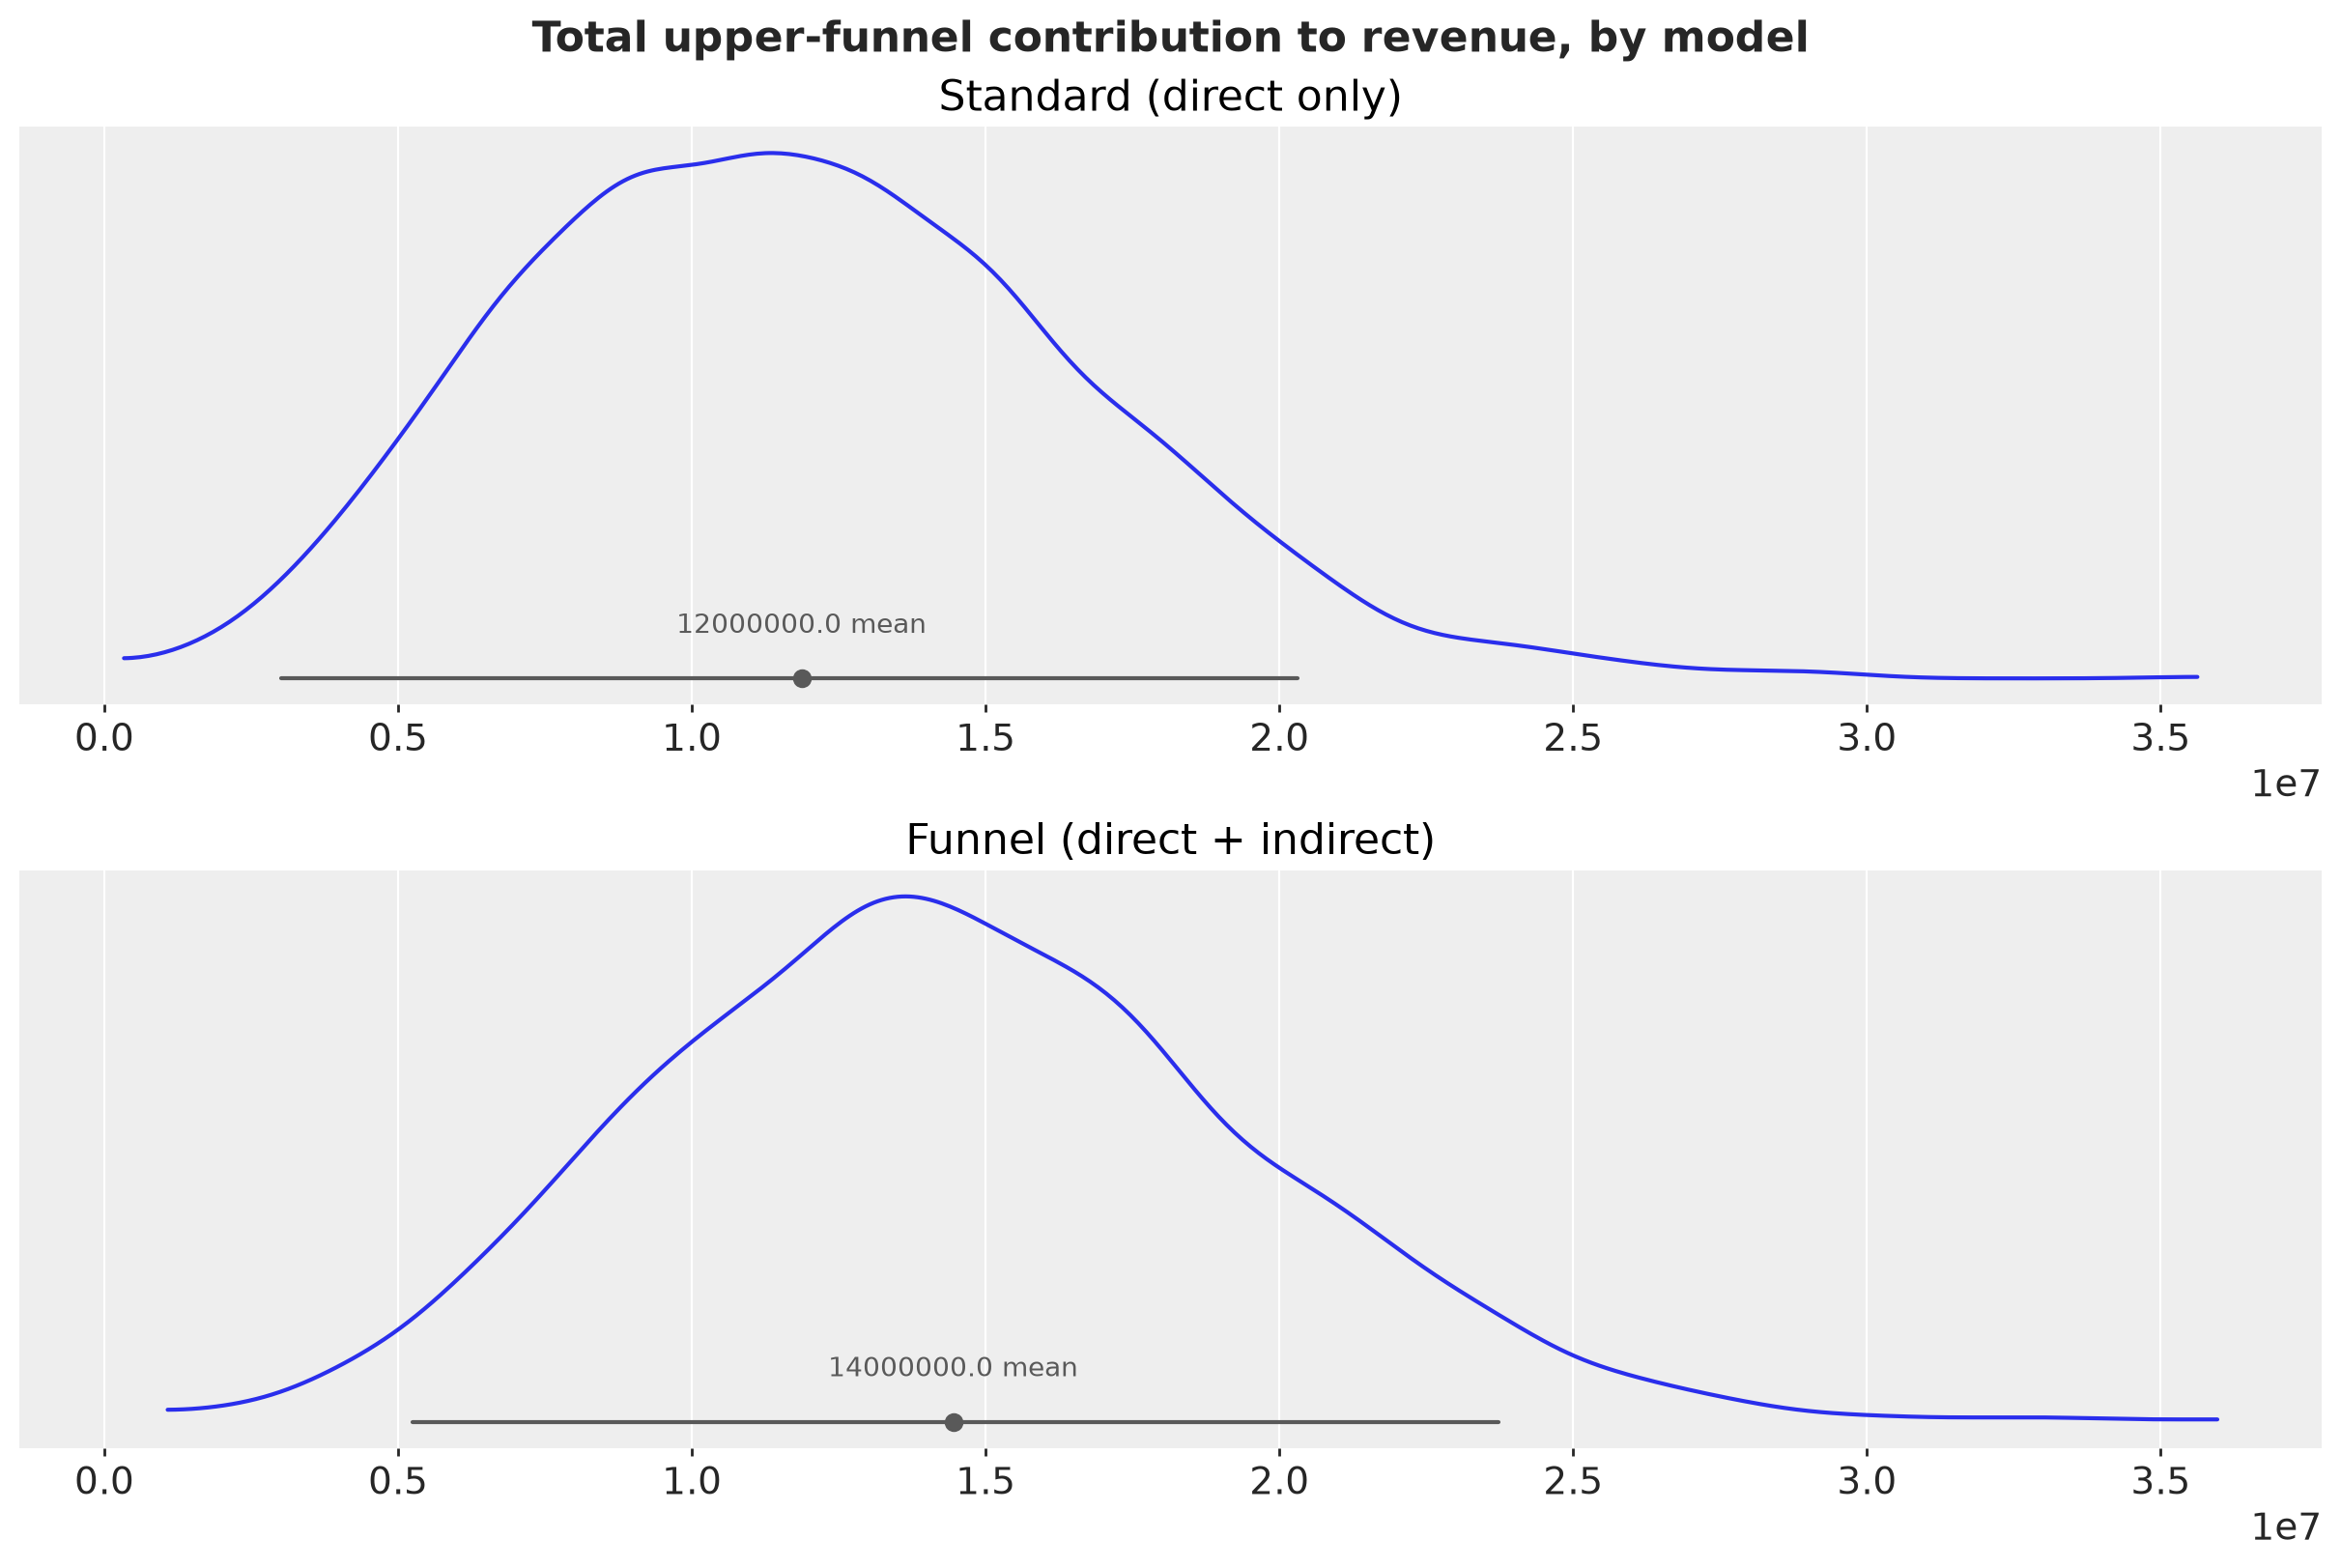

In [19]:
standard_upper = (
    standard.idata.posterior["channel_contribution_original_scale"]
    .sel(channel=upper_channels)
    .sum(dim="channel")
    .mean(dim="date")
)
funnel_upper = total_post.mean(dim="date")


def _bare(da):
    """Drop chain/draw coordinate labels so arrays combine positionally."""
    return da.drop_vars([c for c in ("chain", "draw") if c in da.coords])


contrib_ds = xr.Dataset(
    {
        "Standard (direct only)": _bare(standard_upper),
        "Funnel (direct + indirect)": _bare(funnel_upper),
    }
)

pc = azp.plot_dist(
    contrib_ds,
    col_wrap=1,
    figure_kwargs={"figsize": (12, 8), "sharex": True, "sharey": False, "layout": "constrained"},
)
fig = pc.viz["/"]["figure"].values.item()
for ax, name in zip(fig.axes, contrib_ds.data_vars, strict=True):
    ax.set_title(name)
fig.suptitle("Total upper-funnel contribution to revenue, by model", fontsize=16, fontweight="bold")

lift = float(contrib_ds["Funnel (direct + indirect)"].mean()) / float(contrib_ds["Standard (direct only)"].mean()) - 1
print(f"Funnel model attributes {lift:+.1%} more mean revenue to the upper funnel than the standard model.")


,mean_contribution,roas
Standard,11867115.361,28.466
Funnel,14447209.469,34.655


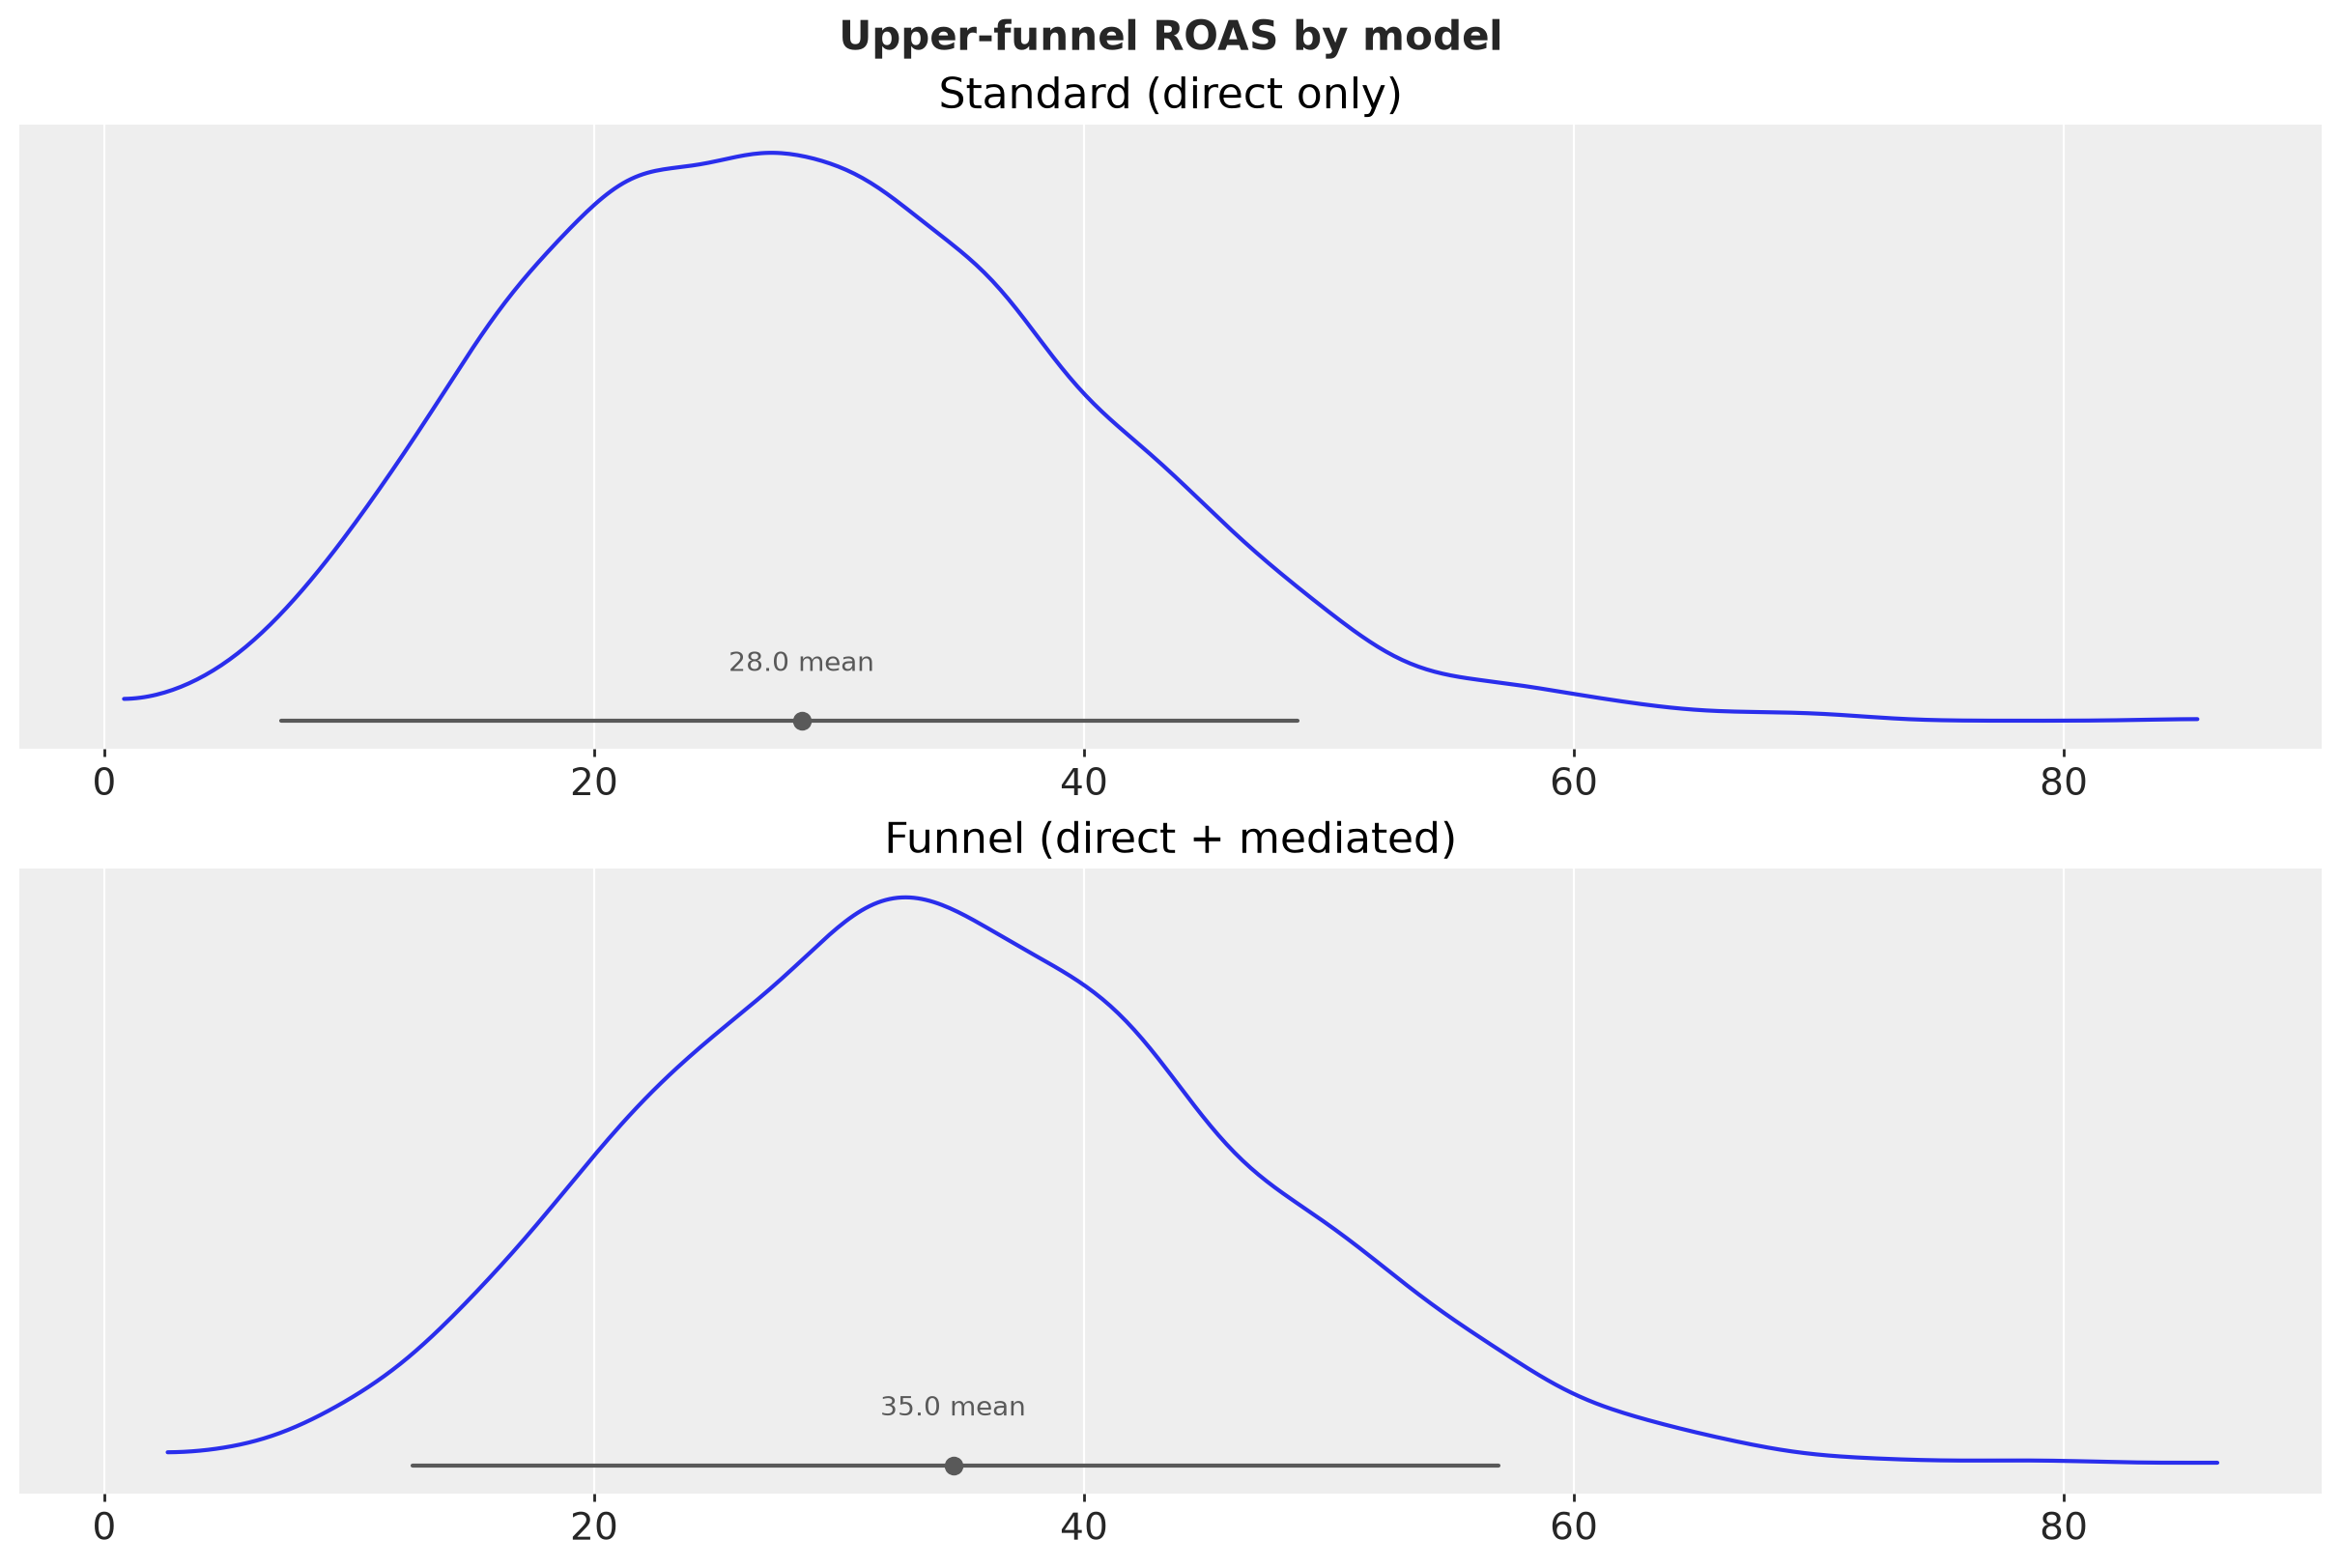

In [21]:
upper_spend_total = float(X[upper_channels].to_numpy().sum())  # total $ spent on upper-funnel channels, all time

# total contribution over total spend, not a sum of each channel's own ratio
roas_standard = (
    standard.idata.posterior["channel_contribution_original_scale"]
    .sel(channel=upper_channels)
    .sum(dim=["channel", "date"])
    / upper_spend_total
)
roas_funnel = total_post.sum(dim="date") / upper_spend_total

roas_ds = xr.Dataset(
    {
        "Standard (direct only)": _bare(roas_standard),
        "Funnel (direct + mediated)": _bare(roas_funnel),
    }
)

pc = azp.plot_dist(
    roas_ds,
    col_wrap=1,
    figure_kwargs={"figsize": (12, 8), "sharex": True, "sharey": False, "layout": "constrained"},
)
fig = pc.viz["/"]["figure"].values.item()
for ax, name in zip(fig.axes, roas_ds.data_vars, strict=True):
    ax.set_title(name)
fig.suptitle("Upper-funnel ROAS by model", fontsize=15, fontweight="bold")

summary = pd.DataFrame(
    {
        "mean_contribution": [float(standard_upper.mean()), float(funnel_upper.mean())],
        "roas": [float(roas_standard.mean()), float(roas_funnel.mean())],
    },
    index=["Standard", "Funnel"],
)
summary.style.format({"mean_contribution": "{:.3f}", "roas": "{:.3f}"})


## How Well Does Each Model Predict?

A model can disagree about *why* revenue happened while still predicting it about equally well, so it's worth checking fit separately from attribution. We look at error metrics on the full dataset, then refit both models on the first 80% of weeks and check how well they predict the last 20%.

**What the next cell does.** `compute_target_metrics(model, y_true, dates=None)` takes a fitted model and the true revenue values, optionally restricted to a `dates` subset, and returns four numbers computed from the posterior-predictive `y_original_scale`: `RMSE` and `R2` from the posterior-mean prediction, `MAPE` (mean absolute percentage error), and `CRPS` (continuous ranked probability score, which scores the full posterior rather than just its mean) via `pymc_marketing.metrics.crps`. It's called once per model on the full dataset, and the four numbers per model are collected into `metrics_rows` and displayed as a table.



In [22]:
def compute_target_metrics(model, y_true: np.ndarray, dates: pd.DatetimeIndex | None = None):
    """Return RMSE, R2, MAPE, and CRPS on the original target scale for posterior-predictive revenue."""
    pp = model.idata.posterior_predictive["y_original_scale"]
    if dates is not None:
        pp = pp.sel(date=pd.to_datetime(dates).to_numpy())
    yhat = pp.mean(dim=[d for d in pp.dims if d != "date"]).to_numpy().ravel()
    y_true = np.asarray(y_true).ravel()
    ss_res = ((y_true - yhat) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    rmse = float(np.sqrt(ss_res / len(y_true)))
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    mape = float(np.mean(np.abs((y_true - yhat) / y_true)))
    y_pred = pp.stack(sample=("chain", "draw")).transpose("sample", "date").to_numpy()
    crps_val = float(crps(y_true, y_pred))
    return rmse, r2, mape, crps_val


metrics_rows = []
for label, m in [("Standard", standard), ("Funnel", funnel)]:
    rmse, r2, mape, crps_val = compute_target_metrics(m, y.to_numpy())
    metrics_rows.append({"model": label, "split": "in_sample", "RMSE": rmse, "R2": r2, "MAPE": mape, "CRPS": crps_val})

pd.DataFrame(metrics_rows).set_index(["model", "split"]).style.format({"RMSE": "{:.2f}", "R2": "{:.4f}", "MAPE": "{:.2%}", "CRPS": "{:.2f}"})


,,RMSE,R2,MAPE,CRPS
model,split,,,,
Standard,in_sample,35262001.37,0.6039,27.08%,19540495.27
Funnel,in_sample,35233453.51,0.6045,27.12%,19541938.23


### Testing on Unseen Weeks

We hold back the most recent 20% of weeks, refit both models on everything before that, and see how well each one predicts the weeks it never saw.

**What the next two cells do.** `holdout_frac` / `n_test` set the split point; `train_df`/`test_df` are the chronological (not shuffled) first-80%/last-20% slices of `data_df`, with `X_train`/`y_train`/`X_test`/`y_test`/`test_dates` derived from them. `fit_holdout_standard` and `fit_holdout_funnel` each build a fresh model on the training window only, fit it with the same `sample_kwargs` used earlier, and call `sample_posterior_predictive` on `X_test` — producing out-of-sample predictions the model never trained on. Their results are stored in `holdout_standard`/`holdout_funnel`.

The second cell reuses `compute_target_metrics` on the holdout predictions to build `holdout_rows`, concatenates them with the earlier in-sample `metrics_rows` into `all_metrics`, and displays the combined table.



In [ ]:
holdout_frac = 0.2
n_test = max(1, int(np.ceil(holdout_frac * len(data_df))))
train_df = data_df.iloc[:-n_test].copy()  # chronological split: train on the past
test_df = data_df.iloc[-n_test:].copy()  # test on the most recent weeks
X_train, y_train = train_df.drop(columns=target_column), train_df[target_column]
X_test = test_df.drop(columns=target_column)
y_test = test_df[target_column].to_numpy()
test_dates = pd.to_datetime(test_df[date_column])


def fit_holdout_standard():
    m = make_standard_mmm(X_train)
    m.build_model(X_train, y_train)
    m.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
    m.fit(X_train, y_train, **sample_kwargs)
    m.sample_posterior_predictive(X_test, random_seed=rng)
    return m


def fit_holdout_funnel():
    m = make_funnel_mmm(X_train)
    m.build_model(X=make_funnel_dataset(X_train, y_train))
    m.add_original_scale_contribution_variable(var=["channel_contribution", "funnel_effect_contribution", "y"])
    m.fit(X=X_train, y=y_train, **sample_kwargs)
    m.sample_posterior_predictive(X_test, random_seed=rng)
    return m


holdout_standard = fit_holdout_standard()
holdout_funnel = fit_holdout_funnel()


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 93 seconds.


Output()

Sampling: [y]


...

/Users/Office/.conda/envs/pymc-marketing-1.0/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 64 seconds.


Output()

Sampling: [funnel_search_impressions_likelihood, y]


Output()

In [44]:
holdout_rows = []
for label, m in [("Standard", holdout_standard), ("Funnel", holdout_funnel)]:
    rmse, r2, mape, crps_val = compute_target_metrics(m, y_test, dates=test_dates)
    holdout_rows.append({"model": label, "split": "holdout", "RMSE": rmse, "R2": r2, "MAPE": mape, "CRPS": crps_val})

all_metrics = pd.concat([pd.DataFrame(metrics_rows), pd.DataFrame(holdout_rows)], ignore_index=True)
all_metrics.set_index(["model", "split"]).style.format({"RMSE": "{:.2f}", "R2": "{:.4f}", "MAPE": "{:.2%}", "CRPS": "{:.2f}"})


,,RMSE,R2,MAPE,CRPS
model,split,,,,
Standard,in_sample,35195451.77,0.6053,27.00%,19498862.13
Funnel,in_sample,35535658.48,0.5977,27.40%,19716367.54
Standard,holdout,37695041.92,0.6105,27.43%,19742518.00
Funnel,holdout,37537028.72,0.6137,26.92%,19566602.13


## Wrapping Up

**What we found**

- Treating `search_spend` as just another channel hides part of the upper funnel's real value: the standard model gives `Broadcast` and `Streaming` less credit than the funnel model does, because it doesn't have anywhere to put the indirect effect.
- The funnel model separates that credit into a direct part and an indirect (search-mediated) part, fitting both alongside the search impressions data at the same time.
- The two models can predict revenue about equally well even though they disagree on attribution — so prediction accuracy alone isn't enough to catch this kind of mistake.

**Things to keep in mind**

- This is real data, so unlike a simulation there's no ground truth to check against — we can only compare the two modeling choices against each other, not against a known right answer.
- We assumed `search_impressions` is purely a measurement of hidden demand, with no independent effect of its own on revenue. If search ads actually drive some incremental sales beyond that, this setup would miss it.
- We didn't calibrate anything against outside experiments, didn't run cross-validation across multiple time windows, and didn't do any budget optimization — this notebook is scoped to attribution only.

**A question worth asking of your own data:** which of your channels might secretly be feeding another channel, instead of acting completely on its own?
